# Calibrated Belief States in Reinforcement Learning for Monetary Policy

## ST455 Reinforcement Learning — Group Project

**Candidate numbers:** 71322, 59423, 68459

**Three-Equation New Keynesian POMDP with PPO and SAC agents under calibrated and overconfident Bayesian forecasters.**

In [ ]:
"""
Cell 0 — Colab Setup
====================
Run this cell first. Installs dependencies, mounts Drive, and sets
the working directory to the shared ST455 project folder.
"""

# Install SB3 and Gymnasium (PyTorch is pre-installed on Colab)
!pip install stable-baselines3[extra] gymnasium --quiet

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# Set working directory
PROJECT_DIR = '/content/drive/MyDrive/ST455 Project'
os.makedirs(PROJECT_DIR, exist_ok=True) # Run if mount fails because of the drive setup
os.chdir(PROJECT_DIR)

# Ensure figures/ exists for Steps 1–5 plots
os.makedirs('figures', exist_ok=True)

# Verify
print("Working directory:", os.getcwd())
print("Drive contents:")
for name in sorted(os.listdir(PROJECT_DIR)):
    print(f"  {name}")

# Quick version check
import stable_baselines3, gymnasium, torch
print(f"\nstable-baselines3 : {stable_baselines3.__version__}")
print(f"gymnasium         : {gymnasium.__version__}")
print(f"torch             : {torch.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()} (not needed for this env)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 6.3 MB/s eta 0:00:00
Mounted at /content/drive
Working directory: /content/drive/.shortcut-targets-by-id/1tLwSra-kcWQP__5BTzzIQzKCdygYlKp3/ST455 Project
Drive contents:
  2026-project-the-q-learners
  Data
  figures
  models
  results
  results_sac

stable-baselines3 : 2.8.0
gymnasium         : 1.2.3
torch             : 2.10.0+cpu
CUDA available    : False (not needed for this env)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Shared display utilities — tables and figures

import pandas as pd
from IPython.display import display, HTML

# Table styling

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '13px'), ('font-weight', 'bold'),
               ('text-align', 'left'), ('padding-bottom', '6px'),
               ('color', 'var(--jp-content-font-color1, #000)')]},
    {'selector': 'thead th',
     'props': [('font-weight', 'bold'), ('font-size', '12px'),
               ('border-bottom', '2px solid #888'),
               ('text-align', 'center'), ('padding', '4px 12px')]},
    {'selector': 'tbody td',
     'props': [('text-align', 'center'), ('font-size', '12px'),
               ('padding', '4px 12px'), ('border-bottom', '1px solid #ddd')]},
    {'selector': 'tbody th',
     'props': [('text-align', 'left'), ('font-size', '12px'),
               ('font-weight', 'normal'), ('padding', '4px 12px'),
               ('border-bottom', '1px solid #ddd')]},
]

def show_table(df, title=None, caption=None):
    if title:
        html = f"<h4 style='margin-bottom:4px'>{title}</h4>"
        if caption:
            html += f"<p style='font-size:11px;color:#666;margin-top:0'>{caption}</p>"
        display(HTML(html))
    display(df.style.set_table_styles(TABLE_STYLES))

# Figure styling defaults

import matplotlib as mpl
import matplotlib.pyplot as plt

FIGURE_STYLE = {
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  9,
    'figure.dpi':       120,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   ':',
}
mpl.rcParams.update(FIGURE_STYLE)

# Shared color palette — use these consistently across all figures
COLORS = {
    "Taylor rule":       "#444441",
    "Full obs PPO":      "#4C72B0",
    "Calibrated PPO":    "#55A868",
    "Overconfident PPO": "#DD8452",
    "SAC calibrated":    "#55A868",
    "SAC overconfident": "#DD8452",
}
LINESTYLES = {
    "Taylor rule":       "--",
    "Full obs PPO":      "-",
    "Calibrated PPO":    "-",
    "Overconfident PPO": "-",
    "SAC calibrated":    "--",
    "SAC overconfident": "--",
}

FIGURES_DIR = "figures"

print("Display utilities loaded.")
print(f"  TABLE_STYLES  — {len(TABLE_STYLES)} selectors")
print(f"  FIGURE_STYLE  — {len(FIGURE_STYLE)} rcParams updated")
print(f"  COLORS        — {list(COLORS.keys())}")

Display utilities loaded.
  TABLE_STYLES  — 4 selectors
  FIGURE_STYLE  — 12 rcParams updated
  COLORS        — ['Taylor rule', 'Full obs PPO', 'Calibrated PPO', 'Overconfident PPO', 'SAC calibrated', 'SAC overconfident']


## Abstract

Modern central banks are increasingly considering machine-learning forecasters
for real-time macroeconomic state estimation, but the policy implications of
forecaster *calibration quality* — the alignment between predictive uncertainty
estimates and the underlying data-generating process — have not been
systematically investigated to our knowledge. We frame the central bank's
decision problem as a partially observable Markov decision process in which the
belief state is supplied by a Bayesian deep-learning forecaster, and ask whether
the calibration of that forecaster's predictive distribution affects the policy
that an RL agent learns on top of it. Our environment is the standard
Three-Equation New Keynesian model, which provides an analytical benchmark policy
(the Taylor rule) and a theoretically-grounded structural criterion (the Taylor
principle, $\phi_\pi > 1$) against which RL policies can be evaluated. We train
PPO and SAC agents under two contrasting belief-state regimes — a calibrated
MS-GLSTM forecaster and an overconfident MC Dropout LSTM whose $\sigma$ values
differ approximately five-fold despite comparable point-prediction accuracy —
together with a full-observability control. Our central finding is that
calibration of the belief state's predictive distribution affects the *structural*
properties of the learned policy more than its raw welfare performance: across
three seeds, the calibrated agent achieves higher mean Taylor coefficient
($\hat{\phi}_{\pi,LR} = 0.967$ vs $0.880$) and is the only POMDP condition that ever clears the determinacy threshold, while the overconfident agent never satisfies
it. On raw welfare loss the overconfident agent outperforms the calibrated agent by roughly 13% — a result that runs counter to the calibration hypothesis on the welfare metric, though we hypothesise it would invert under time-varying uncertainty (Section 7).
The asymmetry is reflected directly in the impulse response behaviour, where
calibrated PPO overshoots the inflation target and overconfident PPO undershoots
— a mechanistic signature of the regression ordering. SAC's entropy-regularised objective substantially reduces the asymmetry —
both conditions satisfy the Taylor principle in at least 2/3 seeds under
SAC, compared to 1/3 and 0/3 under PPO — suggesting PPO's vulnerability
to overconfident inputs is partly an algorithm-specific failure that
maximum-entropy methods can correct. The findings are consistent with the interpretation that
calibration produces a structurally different *kind* of policy — more cautious
and Taylor-aligned under calibrated inputs, more reactive and less
state-contingent under overconfident inputs — rather than simply a better one.

## Section 1: Introduction

Modern central banks are increasingly considering machine-learning forecasters for real-time macroeconomic state estimation. The natural next step — using such forecasters as the input to an automated policy rule — has been explored in recent reinforcement learning work (Chen et al. 2025; Wang et al. 2025), with varying treatment of state uncertainty — Chen et al. consider a deterministic DSGE model in which agents observe the true state, while Wang et al. include Bayesian Q-learning variants that explicitly quantify return-value uncertainty over a fixed transition model. The question of *how the calibration quality of the forecaster's uncertainty estimates affects the policy that an RL agent learns on top of it* has not been systematically investigated. We address this gap.

The setting matters because forecaster calibration and forecaster accuracy are independent properties. Two forecasters can produce equally accurate point predictions while differing dramatically in how their predictive distributions widen during regime change, react to shocks, or quantify their own ignorance. From the perspective of an RL agent, these forecasters present *different* observation spaces — the means may be similar, but the variances supply different information about state uncertainty. If the agent's learned policy depends only on the means, calibration is irrelevant. If the policy structure depends on how uncertainty is communicated, then the calibration of the forecaster materially affects what policy is learned.

We test this empirically. Our environment is the standard Three-Equation New Keynesian model (Clarida, Galí & Gertler, 1999), which provides an analytical benchmark policy (the Taylor rule) and a theoretically-grounded structural criterion (the Taylor principle, $\phi_\pi > 1$) against which RL policies can be evaluated. The agent's belief state is supplied by Bayesian deep-learning forecasters of differing calibration quality, drawn from a parallel ST456 deep learning project: a calibrated MS-GLSTM with CRPS-augmented training loss, and an overconfident MC Dropout LSTM whose uncertainty estimates fail to widen appropriately under the COVID-19 regime change. The forecasters' point-prediction accuracies are similar; their σ values differ by a factor of roughly five. We train PPO and SAC agents under both belief-state conditions and a full-observability control, and evaluate the resulting policies on welfare loss, Taylor principle compliance, impulse-response behaviour, and policy structure.

Our central finding is that **calibration of the belief state's predictive distribution affects the structural properties of the learned policy more than its raw welfare performance**. On welfare loss, the overconfident PPO agent outperforms the calibrated agent ($-6.04$ vs $-6.95$, a gap of approximately 13%), suggesting that within the constant-σ training regime, narrower belief-state uncertainty produces a tighter reactive policy that minimises CB loss more effectively. On Taylor principle compliance, the calibrated agent achieves higher mean $\hat{\phi}_{\pi,LR}$ across three seeds (0.967 vs 0.880) and is the only POMDP condition that ever clears the determinacy threshold; the overconfident agent never satisfies it. The asymmetry is reflected directly in the impulse-response behaviour: calibrated PPO overshoots the inflation target slightly under shock impulses, while overconfident PPO undershoots — a mechanistic signature of the Taylor coefficient ordering. SAC, with its entropy-regularised objective, substantially reduces the asymmetry: both POMDP conditions satisfy the Taylor principle in a majority of seeds, suggesting that PPO's vulnerability to overconfident inputs is partly an algorithm-specific failure that maximum-entropy methods can mitigate.

We interpret these findings as evidence that calibration quality affects the *kind* of policy an RL agent learns, not just how well it performs in-distribution. The overconfident agent learns a tighter, more reactive policy that performs well under the constant-σ noise regime in which it was trained but lacks the Taylor-rule structural properties needed for determinacy. The calibrated agent learns a more cautious, structure-preserving policy whose linear projection onto the Taylor rule basis aligns more closely with the analytical benchmark. We hypothesise that this welfare/structure tradeoff would invert under genuine state-contingent uncertainty rather than the constant-σ regime used here, but testing this requires extending the belief-state model to time-varying uncertainty and is left for future work.

**Working prototype.** This report is implemented as a Jupyter notebook (`st455_nk_monetary_policy_pomdp.ipynb`) which runs end-to-end in Google Colab against pre-trained PPO and SAC models stored on the shared Google Drive. Cell 0 mounts Drive, installs Stable-Baselines3 and Gymnasium, and sets the working directory to `/MyDrive/ST455 Project/`. The expected directory structure contains five top-level folders — `Data/`, `figures/`, `models/`, `results/`, `results_sac/` — together with the notebook itself within `2026-project-the-q-learners/`. From a cold start with all saved models in place, end-to-end runtime is approximately 3–5 minutes; all numerical results are deterministic given the seed-controlled training pipeline. The notebook re-runs every reported result rather than relying on cached outputs, so all tables and figures regenerate from saved models on each execution.

The remainder of the report is organised as follows. Section 2 establishes the standard Three-Equation NK model, the Taylor rule, and the POMDP formulation. Section 3 documents the environment design and validation tests. Section 4 specifies the belief-state structure and the calibrated-vs-overconfident contrast. Section 5 details the training setup. Section 6 presents results across training dynamics (6.1), asymptotic policy quality (6.2), Taylor principle compliance (6.3), episode-length robustness (6.4), an alternative environment specification (6.5), an algorithm comparison with SAC (6.6), impulse response functions (6.7), and policy surface visualisations (6.8). Section 7 discusses the structural-versus-welfare interpretation, limitations, and the relationship between PPO and SAC results. Section 8 concludes.

## Section 2: Background

### 2.1 The Three-Equation New Keynesian Model

The Three-Equation New Keynesian (NK) model is the workhorse framework of modern monetary policy analysis, forming the tractable core of the Dynamic Stochastic General Equilibrium (DSGE) models used by the Federal Reserve, the European Central Bank, and the Bank of England (Clarida et al., 1999). The model describes a monetary economy through three structural relationships: an IS curve governing aggregate demand, a New Keynesian Phillips Curve (NKPC) governing inflation dynamics, and a monetary policy rule. Despite its parsimony, the model captures the key transmission mechanisms through which interest rate decisions affect inflation and output — making it the natural environment for studying reinforcement learning agents acting as central banks.

All variables are expressed in annualised percentage point units, following the convention of Carlin and Soskice (2005). The inflation target is $\pi^* = 2\%$, the natural real interest rate is $r^n = 4\%$, and the steady-state nominal interest rate is $i^* = r^n + \pi^* = 6\%$.

### 2.2 The IS Curve

The IS curve describes aggregate demand dynamics, linking the output gap $x_t$ to the real interest rate:

$$x_{t+1} = x_t - \frac{1}{\sigma}(i_t - \mathbb{E}_t[\pi_{t+1}] - r^n) + \varepsilon^d_{t+1}$$

where $x_t$ is the output gap (the percentage deviation of output from its potential level), $i_t$ is the nominal interest rate set by the central bank, $r^n = 4\%$ is the natural real interest rate, $\sigma = 1.0$ is the intertemporal elasticity of substitution, and $\varepsilon^d_{t+1}$ is a demand shock following an AR(1) process:

$$\varepsilon^d_{t+1} = \rho_d \varepsilon^d_t + \eta^d_{t+1}, \quad \eta^d_{t+1} \sim N(0, \sigma_d^2)$$

with persistence $\rho_d = 0.5$ and standard deviation $\sigma_d = 0.4$.

The key intuition is that raising the nominal interest rate above the natural real rate — making the real rate $i_t - \mathbb{E}_t[\pi_{t+1}]$ exceed $r^n$ — reduces aggregate demand and closes a positive output gap. This is the primary transmission channel through which monetary policy stabilises the economy.

In our implementation, we adopt hybrid expectations following Clarida et al. (1999), where expected inflation is a convex combination of adaptive and target-anchored components:

$$\mathbb{E}_t[\pi_{t+1}] = \omega \pi_t + (1 - \omega)\pi^*$$

with $\omega = 0.7$. Pure adaptive expectations ($\omega = 1$) create a unit-root trap in which inflation never reverts to target within a finite episode, making it impossible for the RL agent to learn a stabilising policy. The hybrid formulation preserves realistic inflation persistence while ensuring a well-defined learning problem.

### 2.3 The New Keynesian Phillips Curve
The New Keynesian Phillips Curve (NKPC) describes inflation dynamics as a function of the output gap and expected future inflation:
$$\pi_{t+1} = \beta \mathbb{E}_t[\pi_{t+1}] + \kappa x_t + \varepsilon^s_{t+1}$$
where $\pi_t$ is the inflation rate, $\beta = 0.99$ is the household discount factor, $\kappa = 0.05$ is the slope of the Phillips curve governing how strongly inflation responds to excess demand, and $\varepsilon^s_{t+1}$ is a cost-push supply shock following an AR(1) process:
$$\varepsilon^s_{t+1} = \rho_s \varepsilon^s_t + \eta^s_{t+1}, \quad \eta^s_{t+1} \sim N(0, \sigma_s^2)$$
with persistence $\rho_s = 0.5$ and standard deviation $\sigma_s = 0.2\%$.

The NKPC arises from the optimal price-setting behaviour of firms facing Calvo-style nominal rigidities (Clarida et al., 1999). A positive output gap ($x_t > 0$) signals excess demand, inducing firms to raise prices and pushing inflation above target. The slope $\kappa$ reflects the degree of price flexibility — a higher $\kappa$ implies faster price adjustment and a stronger inflation response to demand conditions.

Substituting the hybrid expectations formulation, the implemented Phillips curve becomes:
$$\pi_{t+1} = \beta[\omega \pi_t + (1-\omega)\pi^*] + \kappa x_t + \varepsilon^s_{t+1}$$

At steady state, when $x_t = 0$ and $\pi_t = \pi^*$, this reduces to:
$$\pi^* = \beta[\omega\pi^* + (1-\omega)\pi^*] + \kappa \cdot 0 = \beta\pi^* \approx \pi^* \quad \text{(for } \beta \approx 1\text{)} \checkmark$$
This confirms that $\pi^*$ is exactly self-consistent in the limit $\beta \to 1$, and approximately self-consistent for the standard calibration $\beta = 0.99$.

### 2.4 The Taylor Rule

The Taylor rule provides the analytical benchmark policy against which the RL agent is evaluated. It prescribes the nominal interest rate as a linear function of deviations from target:

$$i_t = r^n + \pi^* + \phi_\pi(\pi_t - \pi^*) + \phi_y x_t$$

where $\phi_\pi = 1.5$ is the inflation response coefficient and $\phi_y = 0.5$ is the output gap response coefficient, following the original calibration of Taylor (1993).

At steady state ($\pi_t = \pi^*$, $x_t = 0$), the Taylor rule prescribes $i_t = r^n + \pi^* = i^* = 6\%$, confirming that the steady-state nominal rate equals the sum of the natural real rate and the inflation target.

**The Taylor Principle.** The condition $\phi_\pi > 1$ is known as the Taylor Principle and is necessary for a stable, determinate equilibrium (Clarida et al., 1999). When inflation rises by 1 percentage point, the central bank raises the nominal rate by $\phi_\pi = 1.5$ percentage points, implying a rise in the real rate of 0.5 percentage points. This real rate increase cools aggregate demand and brings inflation back toward target. If $\phi_\pi \leq 1$, higher inflation leads to a lower real rate, which stimulates further demand and inflation — producing explosive, indeterminate dynamics.

The Taylor rule serves two roles in this project. First, it is the analytical benchmark: the RL agent's performance is evaluated relative to the welfare loss achieved by the Taylor rule. Second, it is used as an interpretability tool: the learned policy of the RL agent is regressed on inflation and output gap deviations to extract implicit $\hat{\phi}_\pi$ and $\hat{\phi}_y$ coefficients, testing whether the agent satisfies the Taylor Principle.

### 2.5 Steady-State Derivation

The steady state of the NK model is the unique equilibrium in which all variables are constant period-to-period. Setting $x_{t+1} = x_t = x^*$ and $\pi_{t+1} = \pi_t = \pi^*$ in the three equations and solving simultaneously yields:

**From the IS curve:** at steady state, $x^*$ is constant, so the IS curve requires:

$$0 = -\frac{1}{\sigma}(i^* - \mathbb{E}[\pi^*] - r^n) \implies i^* = r^n + \pi^*$$

**From the Phillips curve:** at steady state with $x^* = 0$:

$$\pi^* = \beta[\omega\pi^* + (1-\omega)\pi^*] + \kappa \cdot 0 = \beta\pi^* \approx \pi^* \quad \text{(for } \beta \approx 1\text{)}$$

**From the Taylor rule:** substituting $\pi_t = \pi^*$ and $x_t = 0$:

$$i^* = r^n + \pi^* + \phi_\pi(\pi^* - \pi^*) + \phi_y \cdot 0 = r^n + \pi^* \checkmark$$

The three equations are mutually consistent at the steady state $(\pi^*, x^*, i^*) = (2\%, 0\%, 6\%)$. However, because $\beta = 0.99 < 1$, the discrete-time fixed point of the system is not exactly $(\pi^*, 0)$ but is displaced from the labelled steady state by $O((1-\beta)\pi^*)$. The hybrid expectations weight $\omega = 0.7$ introduces additional displacement beyond the pure $\beta < 1$ effect. This was confirmed numerically in our implementation: starting from $(\pi^*, 0, i^*)$ and applying the Taylor rule for 200 periods, the system converged to a unique stable attractor at $\pi_\infty \approx 1.9483\%$ and $x_\infty \approx +0.0827$ pp — displaced from the labelled steady state by $\Delta\pi \approx 0.0517$ pp and $\Delta x \approx 0.0827$ pp. This is not a modelling error but a known property of the standard Clarida, Galí and Gertler (1999) Phillips curve in discrete time, documented further in Section 3.1.

### 2.6 Central Bank Loss Function

The central bank minimises a quadratic loss function that penalises deviations of inflation from target and output from potential:

$$L_t = (\pi_t - \pi^*)^2 + \lambda x_t^2$$

where $\lambda = 0.5$ is the relative weight on output gap stabilisation. This loss function reflects the central bank's dual mandate — maintaining price stability ($\pi_t \approx \pi^*$) while supporting maximum employment ($x_t \approx 0$).

The quadratic form has two important properties. First, deviations are penalised symmetrically — overshooting and undershooting the inflation target are equally costly. Second, large deviations are penalised disproportionately relative to small ones, reflecting the empirical observation that tail macroeconomic outcomes are particularly damaging.

In the reinforcement learning framework, the reward signal is the negative of the loss function:

$$r_t = -L_t = -\left[(\pi_t - \pi^*)^2 + \lambda x_t^2\right]$$

A reward of zero represents the perfect outcome — inflation exactly at target and output exactly at potential. More negative rewards correspond to worse macroeconomic outcomes. The RL agent's objective of maximising cumulative discounted reward is therefore equivalent to the central bank's objective of minimising cumulative discounted loss:

$$\max_{\{i_t\}} \mathbb{E}\left[\sum_{t=0}^{T} \gamma^t r_t\right] \equiv \min_{\{i_t\}} \mathbb{E}\left[\sum_{t=0}^{T} \gamma^t \mathcal{L}_t\right]$$

with discount factor $\gamma = 0.99$, consistent with the household discount factor $\beta$ in the NK model.

### 2.7 POMDP Formulation

The standard NK model assumes the central bank observes the true macroeconomic state $(\pi_t, x_t)$ perfectly each period. In practice, real-time data is noisy, subject to revision, and filtered through imperfect forecasting models. We formalise this partial observability as a Partially Observable Markov Decision Process (POMDP).

**True state:** $s_t = (\pi_t, x_t, i_{t-1})$

The true state evolves according to the NK transition dynamics (IS curve and Phillips curve) driven by demand and supply shocks. The central bank does not observe $s_t$ directly.

**Observation:** $o_t = (\hat{\mu}_{\pi,t},\ \hat{\sigma}^2_{\pi,t},\ \hat{\mu}_{x,t},\ \hat{\sigma}^2_{x,t},\ i_{t-1})$

Instead of observing true $(\pi_t, x_t)$, the agent observes probabilistic forecasts from the DL group's Bayesian LSTM models — a mean and variance for each variable. The observation space bounds are:

$$o_t \in [-10, 20] \times [0, 50] \times [-20, 20] \times [0, 50] \times [0, 20]$$

all expressed in annualised percentage point units. The previous interest rate $i_{t-1}$ is always observed exactly, since the central bank knows its own previous decision.

**Action:** $a_t = i_t \in [i_{\min},\ i_{\max}] = [1\%,\ 20\%]$

The action is the nominal interest rate, bounded below by the zero lower bound ($i_{\min} = 1\%$) and above by a practical upper bound ($i_{\max} = 20\%$).

**Reward:** $r_t = -L_t = -\left[(\pi_t - \pi^*)^2 + \lambda x_t^2\right]$

The reward is computed on the true state, not the observed belief state — the central bank is evaluated on actual macroeconomic outcomes regardless of what it believed about the state.

The belief state $o_t$ is provided by two Bayesian LSTM variants from the DL group:

- **Calibrated belief state** — MS-GLSTM predictions, with larger uncertainty estimates ($\hat{\sigma}_\pi \approx 2.254\%$, $\hat{\sigma}_x \approx 0.921$ pp) that widen appropriately during the COVID-19 shock
- **Overconfident belief state** — MC Dropout predictions, with smaller uncertainty estimates ($\hat{\sigma}_\pi \approx 0.456\%$, $\hat{\sigma}_x \approx 0.157$ pp) that fail to widen during the COVID-19 shock

The central empirical question is whether the quality of uncertainty quantification in the belief state — calibration — causally affects the quality of the learned monetary policy.

## Section 3: Environment Design and Validation

### 3.1 Deterministic NK Model: Steady-State Stability and Convergence Validation

Before adding stochastic shocks or training any RL agent, we verify that the structural equations of the NK model are correctly implemented. This is done using a deterministic version of the model — no shocks, no Gym wrapper — applied directly to the NKEnv class-level constants. The incremental approach ensures that any issues identified in later steps can be traced to their source rather than being confounded with model misspecification.

The deterministic system is governed by three equations in annualised percentage point units. The IS curve links the output gap to the real interest rate under hybrid expectations:

$$x_{t+1} = x_t - \frac{1}{\sigma}(i_t - \mathbb{E}_t[\pi_{t+1}] - r^n)$$

where $\mathbb{E}_t[\pi_{t+1}] = \omega\pi_t + (1-\omega)\pi^*$ with $\omega = 0.7$. The Phillips curve describes inflation dynamics:

$$\pi_{t+1} = \beta \mathbb{E}_t[\pi_{t+1}] + \kappa x_t$$

The Taylor rule provides the analytical benchmark policy:

$$i_t = r^n + \pi^* + \phi_\pi(\pi_t - \pi^*) + \phi_y x_t$$

**A note on the discrete-time fixed point.** With $\beta = 0.99 < 1$, the deterministic fixed point of this system is displaced from the labelled steady state $(\pi^*, 0) = (2\%, 0)$ by approximately $O((1-\beta)\pi^*) \approx 0.02$ pp. This is a known property of the standard Clarida, Galí and Gertler (1999) Phillips curve in discrete time — the system does not sit exactly at $\pi^* = 2\%$ but at a unique stable attractor nearby. This is not a modelling error but an inherent feature of the discrete-time approximation.

**Validation Test 1 — Stable Fixed Point.** Starting from the labelled steady state $(\pi^*, 0, i^*) = (2\%, 0, 6\%)$ and applying the Taylor rule for 200 periods, the system converges to a fixed point at $\pi \approx 1.9483\%$ and $x \approx +0.0827$ pp — displaced from the labelled steady state by $\Delta\pi = 0.0517$ pp and $\Delta x = 0.0827$ pp, somewhat larger than the leading-order prediction of $O((1-\beta)\pi^*) \approx 0.02$ pp, as the hybrid expectations weight $\omega = 0.7$ introduces additional displacement beyond the pure $\beta < 1$ effect. The displacement is less than 1.0 pp, confirming the system has a stable fixed point near the labelled steady state.

**Validation Test 2 — Unique Attractor.** Three perturbation scenarios were tested: (A) high inflation only ($\pi_0 = 6\%$, $x_0 = 0$), (B) positive output gap only ($\pi_0 = 2\%$, $x_0 = 5$ pp), and (C) both simultaneously ($\pi_0 = 5\%$, $x_0 = 3$ pp). In all three cases, the Taylor rule returned the economy to the same attractor $(\pi_\infty \approx 1.9483\%, x_\infty \approx +0.0827$ pp) within 200 periods, with deviations from the attractor of less than $4.44 \times 10^{-16}$ (numerical precision). This confirms the system has a **unique** stable attractor — all initial conditions converge to the same point regardless of starting values.

In [ ]:
# =============================================================================
# NKEnv definition + validation
# =============================================================================
# Defines the annualised-% NKEnv and PlaceholderLoader used in Sections 4-6,
# then runs two validation tests on the deterministic system.
#
# Test 1 — Stable fixed point:
#   Start at (π=2%, x=0, i=6%). Apply Taylor rule for 200 periods.
#   Pass condition: displacement from labelled steady state < 1.0pp.
#
# Test 2 — Unique attractor:
#   Three scenarios with Taylor rule applied for 200 periods.
#   Pass condition: all scenarios converge to the same attractor
#   within 4.44e-16 (numerical precision).
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant


# -----------------------------------------------------------------------------
# Belief state loaders (used in Sections 4-6 POMDP work)
# Note: BeliefStateLoader and PlaceholderLoader are defined here alongside
# NKEnv for convenience but are only used in Sections 4-6.
# -----------------------------------------------------------------------------

class BeliefStateLoader(ABC):
    @abstractmethod
    def get(self, t: int, pi_true: float, x_true: float) -> np.ndarray:
        """Return [mu_pi, sigma2_pi, mu_x, sigma2_x] as float32 array."""
    def reset(self, seed=None):
        pass


class PlaceholderLoader(BeliefStateLoader):
    """
    Parametric Gaussian belief state loader.
    sigma_pi and sigma_x are calibrated to the DL group's pre-COVID
    evaluation: MS-GLSTM (calibrated) vs MC Dropout (overconfident).
    See Section 4 for the derivation.
    """
    def __init__(self, sigma_pi, sigma_x, noise_scale=0.01, seed=42):
        self.sigma_pi   = sigma_pi
        self.sigma_x    = sigma_x
        self.noise      = noise_scale
        self._base_seed = seed
        self.rng        = np.random.default_rng(seed)

    def reset(self, seed=None):
        s = seed if seed is not None else self._base_seed
        self.rng = np.random.default_rng(s)

    def get(self, t, pi_true, x_true):
        mu_pi = pi_true + self.rng.normal(0, self.noise)
        mu_x  = x_true  + self.rng.normal(0, self.noise)
        return np.array([mu_pi, self.sigma_pi**2,
                         mu_x,  self.sigma_x**2], dtype=np.float32)


# -----------------------------------------------------------------------------
# NKEnv — annualised %, hybrid expectations, divergence penalty
# -----------------------------------------------------------------------------

class NKEnv(gym.Env):
    """
    Three-Equation New Keynesian model as a Gymnasium environment.
    Units: annualised percentage points (2% target = 2.0).

    Transition (hybrid expectations, omega=0.7):
        IS:   x_{t+1} = x_t - (1/sigma)(i_t - E[pi_{t+1}] - r^n) + eps_d
        NKPC: pi_{t+1} = beta * E[pi_{t+1}] + kappa * x_t + eps_s

    Reward (normalised quadratic CB loss):
        r_t = -[(pi_dev/pi_scale)^2 + lam * (x/x_scale)^2]
        + divergence penalty -200 if state approaches clip boundary
    """

    BETA    = 0.99;   SIGMA   = 1.0;    KAPPA   = 0.05
    PI_STAR = 2.0;    R_N     = 4.0;    LAM     = 0.5
    RHO_D   = 0.5;    RHO_S   = 0.5
    SIGMA_D = 0.4;    SIGMA_S = 0.2

    PHI_PI  = 1.5;    PHI_Y   = 0.5

    I_MIN    = 1.0;   I_MAX     = 20.0
    PI_CLIP  = 6.0;   X_CLIP    = 10.0
    PI_SCALE = 1.0;   X_SCALE   = 2.0
    DIV_PENALTY = 200.0

    def __init__(self, mode='full_obs', loader=None, ep_len=50,
                 seed=42, verbose=False):
        super().__init__()
        assert mode in ('full_obs', 'pomdp_calibrated', 'pomdp_overconf')
        if mode != 'full_obs' and loader is None:
            raise ValueError(f"mode='{mode}' requires a BeliefStateLoader.")

        self.mode    = mode
        self.loader  = loader
        self.ep_len  = ep_len
        self.verbose = verbose
        self.rng     = np.random.default_rng(seed)

        self.action_space = spaces.Box(
            low=self.I_MIN, high=self.I_MAX, shape=(1,), dtype=np.float32)

        if mode == 'full_obs':
            obs_low  = np.array([-10.0, -20.0,  0.0], dtype=np.float32)
            obs_high = np.array([ 20.0,  20.0, 20.0], dtype=np.float32)
        else:
            obs_low  = np.array([-10.0,  0.0, -20.0,  0.0,  0.0], dtype=np.float32)
            obs_high = np.array([ 20.0, 50.0,  20.0, 50.0, 20.0], dtype=np.float32)
        self.observation_space = spaces.Box(
            low=obs_low, high=obs_high, dtype=np.float32)

        self.pi = self.x = self.i_prev = self.eps_d = self.eps_s = self._t = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.pi     = self.PI_STAR
        self.x      = 0.0
        self.i_prev = self.R_N + self.PI_STAR
        self.eps_d  = 0.0
        self.eps_s  = 0.0
        self._t     = 0
        if self.loader is not None:
            self.loader.reset(seed=seed)
        return self._observe(), {}

    def step(self, action):
        i_t = float(np.clip(np.asarray(action).item(), self.I_MIN, self.I_MAX))

        pi_dev = (self.pi - self.PI_STAR) / self.PI_SCALE
        x_dev  = self.x / self.X_SCALE
        reward = -(pi_dev**2 + self.LAM * x_dev**2)

        eps_d_next = self.RHO_D * self.eps_d + self.rng.normal(0.0, self.SIGMA_D)
        eps_s_next = self.RHO_S * self.eps_s + self.rng.normal(0.0, self.SIGMA_S)

        omega      = 0.7
        Et_pi_next = omega * self.pi + (1 - omega) * self.PI_STAR

        x_next  = (self.x
                   - (1.0 / self.SIGMA) * (i_t - Et_pi_next - self.R_N)
                   + eps_d_next)
        pi_next = self.BETA * Et_pi_next + self.KAPPA * self.x + eps_s_next

        diverged = (abs(pi_next - self.PI_STAR) > self.PI_CLIP * 0.9
                    or abs(x_next) > self.X_CLIP * 0.9)
        if diverged:
            reward -= self.DIV_PENALTY

        pi_next = float(np.clip(pi_next,
                                self.PI_STAR - self.PI_CLIP,
                                self.PI_STAR + self.PI_CLIP))
        x_next  = float(np.clip(x_next, -self.X_CLIP, self.X_CLIP))

        self.pi     = pi_next
        self.x      = x_next
        self.i_prev = i_t
        self.eps_d  = eps_d_next
        self.eps_s  = eps_s_next
        self._t    += 1

        terminated = False
        truncated  = self._t >= self.ep_len
        raw_reward = -((self.pi - self.PI_STAR)**2 + self.LAM * self.x**2)
        info       = {"pi": self.pi, "x": self.x, "i": i_t,
                      "reward": raw_reward, "diverged": diverged}
        return self._observe(), reward, terminated, truncated, info

    def _observe(self):
        if self.mode == 'full_obs':
            return np.array([self.pi, self.x, self.i_prev], dtype=np.float32)
        belief = self.loader.get(self._t, self.pi, self.x)
        return np.array([belief[0], belief[1], belief[2], belief[3],
                         self.i_prev], dtype=np.float32)

    def taylor_action(self, clip=False):
        i = (self.R_N + self.PI_STAR
             + self.PHI_PI * (self.pi - self.PI_STAR)
             + self.PHI_Y  * self.x)
        return float(np.clip(i, self.I_MIN, self.I_MAX)) if clip else float(i)

# -----------------------------------------------------------------------------
# Validation: deterministic equation tests (no Gym wrapper, no shocks)
# -----------------------------------------------------------------------------
# These directly exercise the model equations using NKEnv's class-level
# constants. With β<1, the system's deterministic fixed point is displaced
# from the labelled steady state (π*, 0) by O((1-β)π*); we validate that
# the system has a unique stable attractor rather than perfect fixed-point
# stability at the labelled steady state.

PI_STAR = NKEnv.PI_STAR
R_N     = NKEnv.R_N
I_STAR  = R_N + PI_STAR
BETA    = NKEnv.BETA
SIGMA   = NKEnv.SIGMA
KAPPA   = NKEnv.KAPPA
PHI_PI  = NKEnv.PHI_PI
PHI_Y   = NKEnv.PHI_Y
OMEGA   = 0.7 # matches hybrid expectations weight in NKEnv.step()

def nk_step(pi, x, i_t):
    """One deterministic step of the NK model (no shocks)."""
    et_pi = OMEGA * pi + (1 - OMEGA) * PI_STAR
    x_new  = x - (1.0 / SIGMA) * (i_t - et_pi - R_N)
    pi_new = BETA * et_pi + KAPPA * x + 0.0
    return pi_new, x_new

def taylor_rule(pi, x):
    return R_N + PI_STAR + PHI_PI * (pi - PI_STAR) + PHI_Y * x


# -----------------------------------------------------------------------------
# Test 1 — System has a stable fixed point under Taylor rule
# -----------------------------------------------------------------------------
print("=" * 55)
print("TEST 1 — Stable Fixed Point under Taylor Rule")
print("=" * 55)
print(f"Start: π={PI_STAR:.2f}%  x=0.00pp  i={I_STAR:.2f}%")
print(f"Apply Taylor rule for 200 periods. Verify convergence.\n")

pi, x = PI_STAR, 0.0
for t in range(200):
    i_t = taylor_rule(pi, x)
    pi, x = nk_step(pi, x, i_t)

displacement_pi = abs(pi - PI_STAR)
displacement_x  = abs(x)
passed1 = displacement_pi < 1.0 and displacement_x < 1.0

print(f"  Fixed point reached: π={pi:.4f}%  x={x:+.4f}pp")
print(f"  Displacement from labelled steady state:")
print(f"    Δπ = {displacement_pi:.4f}pp  (expected ~{(1-BETA)*PI_STAR:.3f}pp from β<1)")
print(f"    Δx = {displacement_x:.4f}pp")
print(f"  TEST 1 {'PASSED ✓' if passed1 else 'FAILED ✗'}")


# -----------------------------------------------------------------------------
# Test 2 — All initial conditions converge to the same attractor
# -----------------------------------------------------------------------------
print(f"\n{'=' * 55}")
print("TEST 2 — Unique Attractor from All Initial Conditions")
print("=" * 55)

scenarios = {
    "A — High inflation only" : (6.0, 0.0),
    "B — Positive output gap" : (2.0, 5.0),
    "C — Both simultaneously" : (5.0, 3.0),
}

pi_star_attr, x_star_attr = PI_STAR, 0.0
for _ in range(200):
    pi_star_attr, x_star_attr = nk_step(
        pi_star_attr, x_star_attr, taylor_rule(pi_star_attr, x_star_attr))

print(f"\nAttractor (from labelled steady state run):")
print(f"  π_∞ = {pi_star_attr:.6f}%  x_∞ = {x_star_attr:+.6f}pp\n")

all_passed = True
for label, (pi_init, x_init) in scenarios.items():
    pi, x = pi_init, x_init
    print(f"  {label}")
    print(f"  Start: π={pi_init:.2f}%  x={x_init:.2f}pp")
    for t in range(200):
        i_t = taylor_rule(pi, x)
        pi, x = nk_step(pi, x, i_t)
    dev_pi = abs(pi - pi_star_attr)
    dev_x  = abs(x  - x_star_attr)
    converged = dev_pi < 1e-4 and dev_x < 1e-4
    all_passed = all_passed and converged
    print(f"  End  : π={pi:.6f}%  x={x:+.6f}pp")
    print(f"  Dev from attractor: Δπ={dev_pi:.2e}  Δx={dev_x:.2e}")
    print(f"  {'CONVERGED TO ATTRACTOR ✓' if converged else 'NOT CONVERGED ✗'}\n")

passed2 = all_passed
print(f"  TEST 2 {'PASSED ✓' if passed2 else 'FAILED ✗'}")


# -----------------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------------
print(f"\n{'=' * 55}")
print("VALIDATION SUMMARY")
print("=" * 55)
print(f"  Test 1 — Stable fixed point exists, near labelled SS : "
      f"{'PASSED ✓' if passed1 else 'FAILED ✗'}")
print(f"  Test 2 — All initial conditions converge to same attr: "
      f"{'PASSED ✓' if passed2 else 'FAILED ✗'}")
print(f"  Note: discrete-time fixed point is displaced from labelled")
print(f"  steady state by O((1-β)π*) ≈ {(1-BETA)*PI_STAR:.3f}pp due to β<1.")
print(f"  This is a known property of the standard CGG Phillips curve,")
print(f"  derived analytically in Section 2.5 and confirmed numerically here (Section 3.1).")
print("=" * 55)
if passed1 and passed2:
    print("  NKEnv has a unique stable attractor.")
else:
    raise RuntimeError("Validation failed — system lacks a stable attractor.")

TEST 1 — Stable Fixed Point under Taylor Rule
Start: π=2.00%  x=0.00pp  i=6.00%
Apply Taylor rule for 200 periods. Verify convergence.

  Fixed point reached: π=1.9483%  x=+0.0827pp
  Displacement from labelled steady state:
    Δπ = 0.0517pp  (expected ~0.020pp from β<1)
    Δx = 0.0827pp
  TEST 1 PASSED ✓

TEST 2 — Unique Attractor from All Initial Conditions

Attractor (from labelled steady state run):
  π_∞ = 1.948320%  x_∞ = +0.082687pp

  A — High inflation only
  Start: π=6.00%  x=0.00pp
  End  : π=1.948320%  x=+0.082687pp
  Dev from attractor: Δπ=4.44e-16  Δx=4.44e-16
  CONVERGED TO ATTRACTOR ✓

  B — Positive output gap
  Start: π=2.00%  x=5.00pp
  End  : π=1.948320%  x=+0.082687pp
  Dev from attractor: Δπ=4.44e-16  Δx=4.44e-16
  CONVERGED TO ATTRACTOR ✓

  C — Both simultaneously
  Start: π=5.00%  x=3.00pp
  End  : π=1.948320%  x=+0.082687pp
  Dev from attractor: Δπ=4.44e-16  Δx=4.44e-16
  CONVERGED TO ATTRACTOR ✓

  TEST 2 PASSED ✓

VALIDATION SUMMARY
  Test 1 — Stable fixed

### 3.2 Stochastic Shocks and Taylor Rule Dynamics

Having verified the deterministic model, we extend the environment with stochastic shocks to produce realistic macroeconomic fluctuations. Two AR(1) shock processes are added — one entering the IS curve (demand shock) and one entering the Phillips curve (supply shock):

$$\varepsilon^d_{t+1} = \rho_d \varepsilon^d_t + \eta^d_{t+1}, \quad \eta^d_{t+1} \sim \mathcal{N}(0, \sigma_d^2)$$

$$\varepsilon^s_{t+1} = \rho_s \varepsilon^s_t + \eta^s_{t+1}, \quad \eta^s_{t+1} \sim \mathcal{N}(0, \sigma_s^2)$$

with persistence $\rho_d = \rho_s = 0.5$ and standard deviations $\sigma_d = 0.4\%$ p.a. and $\sigma_s = 0.2\%$ p.a., expressed in annualised percentage point units consistent with the rest of the environment. These values are consistent with standard empirical estimates for quarterly NK models (Smets & Wouters, 2007).

The updated transition equations become:

$$x_{t+1} = x_t - \frac{1}{\sigma}(i_t - \mathbb{E}_t[\pi_{t+1}] - r^n) + \varepsilon^d_{t+1}$$

$$\pi_{t+1} = \beta\mathbb{E}_t[\pi_{t+1}] + \kappa x_t + \varepsilon^s_{t+1}$$

where $\mathbb{E}_t[\pi_{t+1}] = \omega\pi_t + (1-\omega)\pi^*$ with $\omega = 0.7$, consistent with the hybrid expectations formulation introduced in Section 2.2.

To confirm that the stochastic environment behaves as expected, we run a single illustrative 200-period trajectory under the Taylor rule. The resulting dynamics confirm the environment is correctly calibrated: inflation has a mean of $1.921\%$ p.a. close to the $2\%$ target, the output gap averages $+0.153$ pp around zero, and the nominal interest rate tracks $i^* = 6\%$ p.a. with a mean of $5.958\%$. The small downward displacement of mean inflation below $\pi^*$ is consistent with the $(1-\beta)\pi^*$ attractor displacement identified in Section 3.1. Quantitative benchmark comparisons between the Taylor rule and the PPO agent are reported in Section 6.2.

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

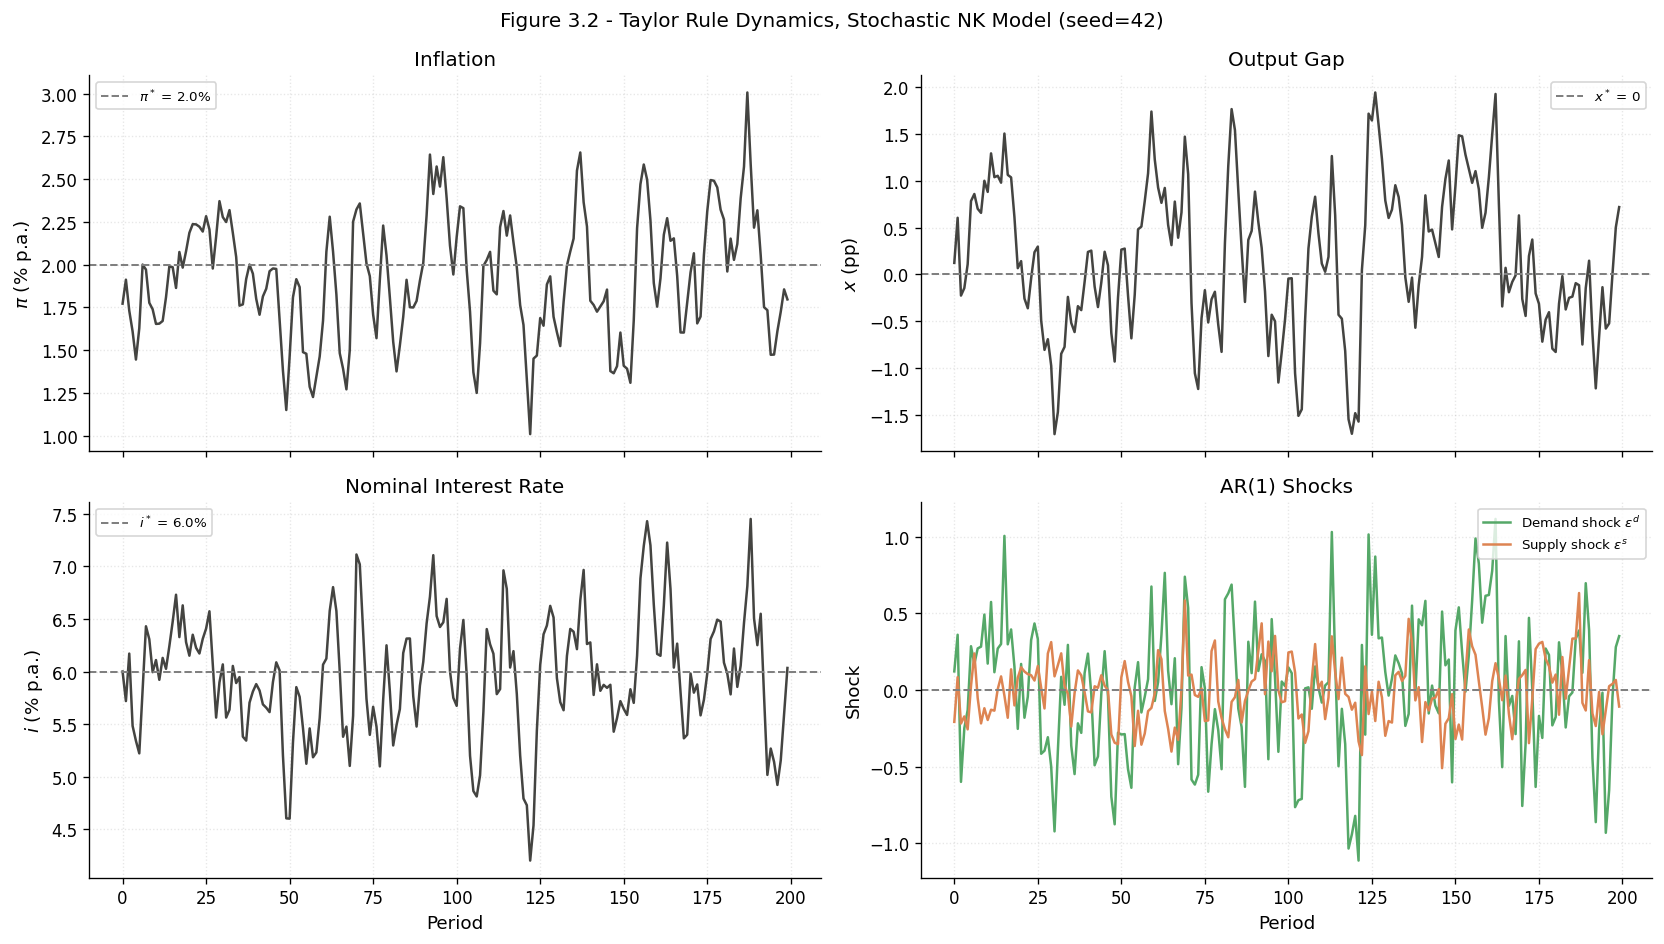

Saved: figures/section3_2_stochastic.png


,Mean,Std,Target
Variable,,,
Inflation $\pi$,1.921%,0.351%,2.0%
Output gap $x$,+0.153pp,0.785pp,0.0pp
Interest rate $i$,5.958%,0.567%,6.0%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# =============================================================================
# Stochastic shocks under the Taylor rule
# =============================================================================
# Single 200-step rollout of NKEnv(mode='full_obs') under the Taylor rule.
# Demonstrates the AR(1) shock processes and confirms the Taylor rule
# stabilises the stochastic economy around the deterministic attractor
# identified in Section 3.1.
#
# Note: this is a single illustrative trajectory. The multi-seed Taylor
# benchmark numbers reported in Section 6.2 are computed over 20 episodes
# of length 20 across seeds {42, 123, 7}.
# =============================================================================

env_demo = NKEnv(mode='full_obs', ep_len=200, seed=42)
obs, _ = env_demo.reset(seed=42)

pi_traj, x_traj, i_traj = [], [], []
eps_d_traj, eps_s_traj = [], []
reward_traj = []

done = False
while not done:
    i_t = env_demo.taylor_action(clip=False)
    obs, _, term, trunc, info = env_demo.step(np.array([i_t]))
    pi_traj.append(info["pi"])
    x_traj.append(info["x"])
    i_traj.append(info["i"])
    eps_d_traj.append(env_demo.eps_d)
    eps_s_traj.append(env_demo.eps_s)
    reward_traj.append(info["reward"])
    done = term or trunc

pi_arr   = np.array(pi_traj)
x_arr    = np.array(x_traj)
i_arr    = np.array(i_traj)
eps_d    = np.array(eps_d_traj)
eps_s    = np.array(eps_s_traj)
reward   = np.array(reward_traj)
t        = np.arange(len(pi_arr))

# -----------------------------------------------------------------------------
# Plot: π, x, i, and the two AR(1) shock processes
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle(r"Figure 3.2 - Taylor Rule Dynamics, Stochastic NK Model (seed=42)", fontsize=12)

axes[0, 0].plot(t, pi_arr, lw=1.5, color=COLORS["Taylor rule"])
axes[0, 0].axhline(NKEnv.PI_STAR, ls="--", lw=1.2, color="gray",
                   label=rf"$\pi^*$ = {NKEnv.PI_STAR:.1f}%")
axes[0, 0].set_title("Inflation")
axes[0, 0].set_ylabel(r"$\pi$ (% p.a.)")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(t, x_arr, lw=1.5, color=COLORS["Taylor rule"])
axes[0, 1].axhline(0.0, ls="--", lw=1.2, color="gray", label=r"$x^*$ = 0")
axes[0, 1].set_title("Output Gap")
axes[0, 1].set_ylabel(r"$x$ (pp)")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(t, i_arr, lw=1.5, color=COLORS["Taylor rule"])
axes[1, 0].axhline(NKEnv.R_N + NKEnv.PI_STAR, ls="--", lw=1.2, color="gray",
                   label=rf"$i^*$ = {NKEnv.R_N + NKEnv.PI_STAR:.1f}%")
axes[1, 0].set_title("Nominal Interest Rate")
axes[1, 0].set_ylabel(r"$i$ (% p.a.)")
axes[1, 0].set_xlabel("Period")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(t, eps_d, lw=1.5, color=COLORS["Calibrated PPO"],
                label=r"Demand shock $\varepsilon^d$")
axes[1, 1].plot(t, eps_s, lw=1.5, color=COLORS["Overconfident PPO"],
                label=r"Supply shock $\varepsilon^s$")
axes[1, 1].axhline(0.0, ls="--", lw=1.2, color="gray")
axes[1, 1].set_title("AR(1) Shocks")
axes[1, 1].set_ylabel("Shock")
axes[1, 1].set_xlabel("Period")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section3_2_stochastic.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/section3_2_stochastic.png")

# -----------------------------------------------------------------------------
# Summary statistics
# -----------------------------------------------------------------------------
summary_data = {
    "Variable":  ["Inflation $\\pi$", "Output gap $x$", "Interest rate $i$"],
    "Mean":      [f"{pi_arr.mean():.3f}%", f"{x_arr.mean():+.3f}pp", f"{i_arr.mean():.3f}%"],
    "Std":       [f"{pi_arr.std():.3f}%",  f"{x_arr.std():.3f}pp",   f"{i_arr.std():.3f}%"],
    "Target":    [f"{NKEnv.PI_STAR:.1f}%", "0.0pp",
                  f"{NKEnv.R_N + NKEnv.PI_STAR:.1f}%"],
}
df_summary = pd.DataFrame(summary_data).set_index("Variable")
show_table(
    df_summary,
    title="Table 3.2 — Stochastic Simulation Summary (200 periods, Taylor rule)",
    caption=(f"Mean π is {NKEnv.PI_STAR - pi_arr.mean():.3f}pp below target "
             f"due to the (1−β)π* attractor displacement (Section 3.1).")
)

### 3.3 Gym-Compatible Environment Wrapper for Stable-Baselines3

The NK model is implemented as a Gymnasium environment, making it directly compatible with Stable-Baselines3 (SB3) for agent training.

**Observation space:** $[\pi_t, x_t, i_{t-1}] \in [-10, 20] \times [-20, 20] \times [0, 20]$

All values in annualised percentage point units. The agent observes current inflation, the output gap, and the interest rate set in the previous period.

**Action space:** $i_t \in [i_{\min}, i_{\max}] = [1\%, 20\%]$

The nominal interest rate is bounded below by an effective lower bound of $1\%$ and above by $20\%$.

**Reward function:** the environment implements the normalised negative quadratic CB loss with a divergence penalty:

$$r_t = -\left[\left(\frac{\pi_t - \pi^*}{\pi_{\text{scale}}}\right)^2 + \lambda\left(\frac{x_t}{x_{\text{scale}}}\right)^2\right] - 200 \cdot \mathbf{1}_{\text{diverged}}$$

where $\pi_{\text{scale}} = 1.0$, $x_{\text{scale}} = 2.0$, and the divergence penalty of $-200$ is applied when the state approaches the clip boundary. The penalty discourages explosive dynamics without terminating the episode, which would distort mean reward comparisons across conditions.

The environment was verified using SB3's `check_env` utility, confirming compatibility with the Gymnasium interface before training.

In [ ]:
# =============================================================================
# Gym wrapper sanity check
# =============================================================================
# Confirms NKEnv passes SB3's environment checker before training.
# Checks observation space, action space, and step/reset interface.
# =============================================================================

from stable_baselines3.common.env_checker import check_env

env_check = NKEnv(mode='full_obs', ep_len=20, seed=42)
check_env(env_check, warn=True)
print("SB3 check_env passed ✓")
print(f"  Observation space : {env_check.observation_space}")
print(f"  Action space      : {env_check.action_space}")

SB3 check_env passed ✓
  Observation space : Box([-10. -20.   0.], 20.0, (3,), float32)
  Action space      : Box(1.0, 20.0, (1,), float32)


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


## Section 4: Forecaster Evaluation, Belief State Design, and POMDP Formulation

Section 2.7 formalised the central bank's decision problem as a POMDP in
which the true state $(\pi_t, x_t, i_{t-1})$ is hidden and the agent
observes a belief state derived from a forecaster. This section describes
the source data and forecaster evaluation underlying the belief-state
$\sigma$ values (4.1), specifies the belief-state structure (4.2),
characterises the calibrated-vs-overconfident contrast that constitutes
our central experimental manipulation (4.3), and documents the
PlaceholderLoader implementation used during training (4.4).

### 4.1 Source Data and Forecaster Evaluation

**Data.** Both forecasters are trained on six U.S. macroeconomic series
sourced from FRED, covering January 2000 through December 2024 (299 monthly
observations after alignment): CPI inflation $\pi_t$ (annualised m/m),
the negated unemployment gap $x_t$ (output gap proxy), the VIX volatility
index, log-differenced industrial production, the 10Y–2Y Treasury spread,
and the HP-filtered GDP gap (quarterly, upsampled by carry-forward). The
two forecasting targets — $\pi_t$ and $x_t$ — are also the state variables
of the NK environment. Data are split strictly temporally: training
2000–2017, validation 2018–2019, and three test regimes — pre-COVID
(2015–2019), COVID shock (2020–2021), and post-COVID (2022–2024) — with
no lookahead. All features are standardised by training-window statistics
applied unchanged to subsequent windows.

**Forecasters.** The **calibrated** forecaster is the Multi-Scale Gaussian
LSTM (MS-GLSTM), a dual-stream encoder with a heteroscedastic Gaussian head
trained on a joint NLL + CRPS loss that explicitly rewards calibration of
the predictive distribution. The **overconfident** forecaster is an MC
Dropout LSTM, which approximates a Bayesian posterior via inference-time
dropout but optimises NLL only, without explicit calibration. Both
forecasters are evaluated on the same pre-COVID test period.

**Table 4.1 — Forecaster Comparison: Calibration vs Point Accuracy**

| Metric | MS-GLSTM (calibrated) | MC Dropout (overconfident) |
|---|---|---|
| ECE (pre-COVID) | **0.033** | 0.356 |
| CRPS (pre-COVID) | 0.348 | 0.402 |
| $\hat{\sigma}_\pi$ (pre-COVID, normalised) | 0.620 | 0.126 |
| $\hat{\sigma}_\pi$ (pre-COVID, annualised %) | **2.254%** | 0.456% |
| $\hat{\sigma}_x$ (pre-COVID, pp) | **0.921 pp** | 0.157 pp |
| COVID/Pre $\hat{\sigma}_\pi$ ratio | **1.133×** ↑ | 0.981× ↓ |

The table isolates the experimental design: The calibration gap is unambiguous: MS-GLSTM achieves an ECE of 0.033 versus 0.356 for MC Dropout — an order-of-magnitude difference on a metric that measures interval coverage directly, independently of point accuracy. The CRPS values are closer (0.348 vs 0.402), consistent with the two forecasters achieving similar point-prediction accuracy; however, CRPS conflates accuracy and calibration so we cannot fully isolate the variance channel from the mean channel without RMSE/MAE, which we do not report here. The divergence is entirely in calibration — MS-GLSTM's ECE is an order of magnitude lower (0.033 vs 0.356), and its intervals widen appropriately during the COVID shock (ratio $> 1$) while MC Dropout's narrow (ratio $< 1$). This confirms that the $\sigma$ contrast used in the RL experiment is not arbitrary — it reflects a genuine difference in distributional calibration quality, not forecasting skill.

**Unit conversion.** The DL models output uncertainty estimates in
standardised units, since all features are normalised by their
training-window mean and standard deviation before being fed to the
network. To use these $\hat{\sigma}$ values as belief-state inputs to
NKEnv — which operates in annualised percentage points — we apply the
inverse standardisation. For inflation, the training-window standard
deviation of the annualised m/m CPI series is $s_\pi = 0.03635$ (in
decimal log-return units), so the conversion is $\hat{\sigma}_\pi^{\%}
= \hat{\sigma}_\pi^{\text{norm}} \times s_\pi \times 100$. For the
output gap, the training-window standard deviation of the negated
unemployment gap is $s_x = 1.73551$ pp, giving $\hat{\sigma}_x^{\text{pp}}
= \hat{\sigma}_x^{\text{norm}} \times s_x$. Applying these conversions
to the pre-COVID evaluation outputs yields the belief-state $\sigma$
values used throughout the RL experiment: $\hat{\sigma}_\pi = 2.254\%$
and $\hat{\sigma}_x = 0.921$ pp for the calibrated condition, and
$\hat{\sigma}_\pi = 0.456\%$ and $\hat{\sigma}_x = 0.157$ pp for the
overconfident condition — a ratio of approximately $4.9\times$ on the
inflation uncertainty dimension.

### 4.2 Belief State Structure

At each period $t$, the central bank observes a five-dimensional vector $b_t = (\hat{\mu}_{\pi,t}, \hat{\sigma}^2_{\pi,t}, \hat{\mu}_{x,t}, \hat{\sigma}^2_{x,t}, i_{t-1})$. The first four components are the means and variances of the forecaster's predictive distributions over inflation and the output gap; the fifth is the central bank's previous interest rate, which is observed exactly. The reward, however, is computed on the *true* state $(\pi_t, x_t)$ — the central bank is evaluated on actual macroeconomic outcomes regardless of what its belief state told it. This decoupling between observation and reward is what makes the POMDP non-trivial: a poorly-calibrated forecaster can still correctly predict the mean state, but if its variance estimates are mismatched to the actual uncertainty, the agent must decide how aggressively to act on those means in a way that the forecaster itself does not encode.

### 4.3 Calibrated vs Overconfident Forecasters

We use two Bayesian LSTM variants from a parallel ST456 deep learning project as the source of the belief-state σ values. The calibrated variant is a multi-scale Gaussian LSTM (MS-GLSTM) trained with a CRPS-augmented loss that explicitly rewards calibration of the predictive distribution. On the pre-COVID test period, this forecaster produces predictive standard deviations of $\hat{\sigma}_\pi \approx 2.254\%$ p.a. for inflation and $\hat{\sigma}_x \approx 0.921$ pp for the output gap. The overconfident variant is an MC Dropout LSTM whose dropout-derived uncertainty estimates do not widen appropriately during the COVID-19 regime change. On the same pre-COVID test period, this forecaster produces $\hat{\sigma}_\pi \approx 0.456\%$ and $\hat{\sigma}_x \approx 0.157$ pp — narrower by approximately 4.9×. Importantly, the two forecasters achieve similar point-prediction accuracy on the test set; their difference is in the calibration of their predictive distributions, not in their means. This asymmetry — same means, different variances — is the empirical lever through which we test whether calibration quality, holding accuracy approximately constant, affects the learned policy.

**MC Dropout as approximate Bayesian inference.** MC Dropout produces predictive distributions by performing forward passes through a network with dropout enabled at inference time and treating the resulting variability as posterior uncertainty. Gal & Ghahramani (2016) show that this procedure is equivalent, under certain regularity conditions, to variational inference in a deep Gaussian process — i.e. it has a principled Bayesian interpretation as approximate posterior sampling. We treat the resulting σ values as legitimate uncertainty estimates rather than as ad-hoc dropout noise, and the "overconfident" label refers specifically to the *calibration* of those estimates relative to the underlying data-generating process: MC Dropout systematically underestimates predictive variance under regime change. The contrast in this paper is therefore between two principled Bayesian approximations of differing calibration quality, not between Bayesian and non-Bayesian methods.


### 4.4 Implementation: PlaceholderLoader

During RL training, the belief state is supplied to the agent via a `PlaceholderLoader` — a parametric Gaussian generator constructed as follows: the σ values are taken directly from the forecaster evaluations above and held *constant* across all training timesteps, while the means $(\hat{\mu}_{\pi,t}, \hat{\mu}_{x,t})$ are generated by adding small Gaussian noise (scale $0.01$) to the current true state. This implementation choice is deliberate but has a known limitation that bears on the interpretation of our results: by construction, the agent observes near-perfect means with belief-state uncertainty entering only through the variance channel. A real DL forecaster would produce noisier means, and crucially, would produce *time-varying* σ values that respond to incoming data. The constant-σ assumption is therefore a conservative test of the calibration hypothesis: any difference between the calibrated and overconfident agents must be attributable to the magnitude of σ alone, not to its dynamics. We hypothesise (Section 7) that the welfare ordering observed in Section 6.2 — where overconfident PPO marginally outperforms calibrated on raw CB loss — would invert under time-varying σ that responds to genuine state uncertainty, but testing this requires extending the loader and is left for future work.

## Section 5: Training Setup

We train PPO agents under three observation conditions: full observability (the agent sees the true state $(\pi_t, x_t, i_{t-1})$), POMDP with calibrated belief states (MS-GLSTM σ values), and POMDP with overconfident belief states (MC Dropout σ values). Each condition is run with three random seeds $\{42, 123, 7\}$ for a total of nine PPO training runs.

**Hyperparameters.** All PPO runs use identical hyperparameters: $n_{\text{steps}} = 2048$, batch size $= 64$, $n_{\text{epochs}} = 10$, learning rate $\alpha = 3 \times 10^{-4}$, $\gamma = 0.99$, $\lambda_{\text{GAE}} = 0.95$, clip range $\epsilon = 0.2$, entropy coefficient $c_{\text{ent}} = 0.01$, value-function coefficient $c_{\text{vf}} = 0.5$, gradient clipping at $0.5$, and a two-layer MLP $(64, 64)$ for both the policy and value networks. Each run trains for $10^6$ environment steps. The actor's output bias is initialised at $i^* = 6\%$ before training begins, which prevents early-training divergence into the action-space boundaries — without this initialisation, the agent's initial random policy frequently triggers the divergence penalty and learning is slow to recover.

**Evaluation protocol.** All evaluation results are computed from saved models loaded from `results/{condition}_seed{seed}/model.zip`. The evaluation procedure runs each trained agent deterministically (using the policy mean rather than sampling) over 20 episodes of length 20 in an environment seeded with $\text{seed}$, with the belief-state loader re-initialised with $\text{seed}+1$ to ensure that evaluation belief means are drawn from a different sequence than training while remaining deterministic and reproducible. Reported rewards are the *raw* per-episode CB loss $-\sum_t [(\pi_t - \pi^*)^2 + \lambda x_t^2]$ rather than the normalised reward used during training; episodes with state-space divergence (reward penalty triggered) are flagged but included in the mean. In practice, no divergences were observed across any condition, seed, or evaluation episode in the reported results — the trained agents reliably keep the state within the linearisation bounds. The Taylor regression results in Section 6.3 are estimated on the stacked deterministic evaluation trajectories, with HC3 robust standard errors.

**SAC comparison.** For the algorithm-comparison results in Section 6.6, we additionally train SAC agents on the two POMDP conditions using identical environment, evaluation, and seed setup. SAC hyperparameters are: learning rate $\alpha = 3 \times 10^{-4}$, replay buffer size $= 10^5$, learning starts after $10^3$ steps, batch size $= 256$, $\tau = 0.005$, $\gamma = 0.99$, automatic entropy coefficient tuning, and a two-layer MLP $(64, 64)$. SAC trains for $5 \times 10^5$ steps per run, half the PPO budget; despite this, both SAC POMDP conditions converge to asymptotic reward in approximately $10^4$ steps — roughly 50–90× faster than PPO (Section 6.6).

**Note on the Taylor regression as a linear projection.** The Taylor principle test in Section 6.3 fits an OLS regression of the form $\hat{i}_t = \alpha + \rho \hat{i}_{t-1} + \hat{\phi}_\pi(\hat{\mu}_{\pi,t} - \pi^*) + \hat{\phi}_y \hat{\mu}_{x,t}$ on the agent's deterministic eval trajectories. This regression captures only the *linear projection* of the agent's policy onto the Taylor rule basis. A finding of $\hat{\phi}_{\pi,LR} < 1$ does not imply that the learned policy produces unstable dynamics — Section 3.1 already established that the environment has a stable attractor under any policy that respects the Taylor principle in expectation, and the bounded mean rewards reported in Section 6.2 confirm that all four policies stabilise the system. Rather, $\hat{\phi}_{\pi,LR} < 1$ indicates that the policy's stabilisation mechanism is not fully captured by a linear-in-state rule; the policy may still be stabilising via nonlinear or higher-order responses that the linear regression cannot represent. We treat the Taylor coefficients as projections onto a structural basis, not as a direct measure of policy stability, and rely on the IRF and policy surface analyses in Sections 6.7 and 6.8 to characterise the actual policies. The regression also reports $R^2$ as a diagnostic of how linearly explainable each policy is by the Taylor rule basis — a higher $R^2$ indicates the agent's rate-setting behaviour is more closely approximated by a linear-in-state rule, which need not imply better Taylor compliance, as Section 6.3 shows.

In [ ]:
# =============================================================================
# Main POMDP cell — PPO across four conditions, three seeds
# =============================================================================
# Conditions:
#   1. taylor_rule          — analytical baseline, no training
#   2. full_obs_rl          — PPO on true state (π, x, i_{t-1})
#   3. pomdp_calibrated     — PPO on belief state with MS-GLSTM σ values
#   4. pomdp_overconfident  — PPO on belief state with MC Dropout σ values
#
# Saved models load from results/ if present — no retraining on clean run.
# All results stored in all_seed_results, all_eval_results, regression_results
# for display in Section 6.
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

RESULTS_DIR   = "results"
SEED          = 42
SEEDS         = [42, 123, 7]
TOTAL_STEPS   = 1_000_000
EVAL_EPISODES = 20
os.makedirs(RESULTS_DIR, exist_ok=True)

# -----------------------------------------------------------------------------
# Sigma values from DL pre-COVID evaluation (normalised → annualised %)
# -----------------------------------------------------------------------------
I_STAR_NK = NKEnv.R_N + NKEnv.PI_STAR   # 6.0%

_PI_STD = 0.03635;  _PCT = 100.0;  _X_STD = 1.73551

SIGMA_PI_CALIB = 0.6201 * _PI_STD * _PCT   # MS-GLSTM   → 2.254% p.a.
SIGMA_X_CALIB  = 0.5305 * _X_STD           # MS-GLSTM   →  0.920pp
SIGMA_PI_OVERC = 0.1255 * _PI_STD * _PCT   # MC Dropout → 0.456% p.a.
SIGMA_X_OVERC  = 0.0906 * _X_STD           # MC Dropout →  0.157pp

print(f"Belief state sigma values (DL pre-COVID evaluation):")
print(f"  Calibrated    (MS-GLSTM):   "
      f"σ_π={SIGMA_PI_CALIB:.3f}%  σ_x={SIGMA_X_CALIB:.3f}pp")
print(f"  Overconfident (MC Dropout): "
      f"σ_π={SIGMA_PI_OVERC:.3f}%  σ_x={SIGMA_X_OVERC:.3f}pp")
print(f"  Sigma ratio (calib/overconf): {SIGMA_PI_CALIB/SIGMA_PI_OVERC:.1f}×")

# -----------------------------------------------------------------------------
# PPO setup
# -----------------------------------------------------------------------------

PPO_KWARGS = dict(
    learning_rate  = 3e-4,
    n_steps        = 2048,
    batch_size     = 64,
    n_epochs       = 10,
    gamma          = 0.99,
    gae_lambda     = 0.95,
    clip_range     = 0.2,
    ent_coef       = 0.01,
    vf_coef        = 0.5,
    max_grad_norm  = 0.5,
    policy_kwargs  = dict(net_arch=dict(pi=[64, 64], vf=[64, 64])),
    verbose        = 0,
    seed           = SEED,
)


def bias_actor(model, i_star=I_STAR_NK):
    low, high = NKEnv.I_MIN, NKEnv.I_MAX
    a_norm    = float(np.clip(2.0*(i_star-low)/(high-low) - 1.0, -0.999, 0.999))
    z_target  = float(np.arctanh(a_norm))
    with torch.no_grad():
        model.policy.action_net.bias.fill_(z_target)
    print(f"  Actor bias → z={z_target:.4f}, initial mean action ≈ {i_star:.2f}%")


def make_conditions():
    calibrated_loader = PlaceholderLoader(
        sigma_pi=SIGMA_PI_CALIB, sigma_x=SIGMA_X_CALIB,
        noise_scale=0.01, seed=SEED)
    overconfident_loader = PlaceholderLoader(
        sigma_pi=SIGMA_PI_OVERC, sigma_x=SIGMA_X_OVERC,
        noise_scale=0.01, seed=SEED)
    return [
        ("taylor_rule",         None),
        ("full_obs_rl",         Monitor(NKEnv(mode='full_obs',
                                              ep_len=20, seed=SEED))),
        ("pomdp_calibrated",    Monitor(NKEnv(mode='pomdp_calibrated',
                                              ep_len=20, seed=SEED,
                                              loader=calibrated_loader))),
        ("pomdp_overconfident", Monitor(NKEnv(mode='pomdp_overconf',
                                              ep_len=20, seed=SEED,
                                              loader=overconfident_loader))),
    ]


class EpisodeLogCallback(BaseCallback):
    def __init__(self, log_freq=10):
        super().__init__()
        self.log_freq  = log_freq
        self.records   = []
        self._ep_count = 0

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self._ep_count += 1
                if self._ep_count % self.log_freq == 0:
                    self.records.append({
                        "episode":     self._ep_count,
                        "mean_reward": info["episode"]["r"],
                        "timestep":    self.num_timesteps,
                    })
        return True

    def as_dataframe(self):
        return pd.DataFrame(self.records)


def evaluate(model_or_none, condition_name, n_episodes=EVAL_EPISODES, seed=SEED):
    """Deterministic eval. Returns raw CB loss; divergence excluded."""
    pi_all, x_all, i_all, r_all = [], [], [], []
    mu_pi_all, mu_x_all         = [], []
    diverge_count               = 0

    if condition_name == "taylor_rule":
        env = NKEnv(mode='full_obs', ep_len=20, seed=seed)
        for ep in range(n_episodes):
            obs, _ = env.reset(seed=seed + ep)
            done   = False
            while not done:
                i_t = env.taylor_action(clip=False)
                obs, _, term, trunc, info = env.step(np.array([i_t]))
                pi_all.append(info["pi"]);    x_all.append(info["x"])
                i_all.append(i_t);            r_all.append(info["reward"])
                mu_pi_all.append(info["pi"]); mu_x_all.append(info["x"])
                done = term or trunc
    else:
        if "calibrated" in condition_name and "over" not in condition_name:
            loader = PlaceholderLoader(
                sigma_pi=SIGMA_PI_CALIB, sigma_x=SIGMA_X_CALIB,
                noise_scale=0.01, seed=seed+1)
            mode = 'pomdp_calibrated'
        elif "overconf" in condition_name:
            loader = PlaceholderLoader(
                sigma_pi=SIGMA_PI_OVERC, sigma_x=SIGMA_X_OVERC,
                noise_scale=0.01, seed=seed+1)
            mode = 'pomdp_overconf'
        else:
            loader, mode = None, 'full_obs'

        env = NKEnv(mode=mode, ep_len=20, seed=seed, loader=loader)
        for ep in range(n_episodes):
            obs, _ = env.reset(seed=seed + ep)
            done   = False
            while not done:
                action, _ = model_or_none.predict(obs, deterministic=True)
                obs, _, term, trunc, info = env.step(action)
                pi_all.append(info["pi"]);  x_all.append(info["x"])
                i_all.append(info["i"]);    r_all.append(info["reward"])
                if info["diverged"]:
                    diverge_count += 1
                if mode != 'full_obs' and loader is not None:
                    belief = loader.get(env._t - 1, info["pi"], info["x"])
                    mu_pi_all.append(float(belief[0]))
                    mu_x_all.append(float(belief[2]))
                else:
                    mu_pi_all.append(info["pi"])
                    mu_x_all.append(info["x"])
                done = term or trunc

    total_steps = len(r_all)
    if diverge_count > 0:
        print(f"  ⚠ divergence: {diverge_count}/{total_steps} steps "
              f"({100*diverge_count/total_steps:.1f}%)")

    return (np.array(pi_all),    np.array(x_all),
            np.array(i_all),     np.array(r_all),
            np.array(mu_pi_all), np.array(mu_x_all))


# -----------------------------------------------------------------------------
# Training loop
# -----------------------------------------------------------------------------

all_seed_results = {name: [] for name, _ in make_conditions()}
all_eval_results = {}

for run_seed in SEEDS:
    print(f"\n{'#'*60}\n  SEED = {run_seed}\n{'#'*60}")
    trained      = {}
    eval_results = {}

    for name, env in make_conditions():
        cond_dir = os.path.join(RESULTS_DIR, f"{name}_seed{run_seed}")
        os.makedirs(cond_dir, exist_ok=True)
        print(f"\n  Condition: {name}  (seed={run_seed})")

        if name == "taylor_rule":
            print("  Analytical baseline — no training.")
            trained[name] = None
        else:
            model_path = os.path.join(cond_dir, "model.zip")
            if os.path.exists(model_path):
                print(f"  Loading saved model from {model_path}")
                vec_env = DummyVecEnv([lambda e=env: e])
                model   = PPO.load(model_path, env=vec_env)
                trained[name] = model
            else:
                print(f"  Training from scratch...")
                vec_env = DummyVecEnv([lambda e=env: e])
                cb      = EpisodeLogCallback(log_freq=10)
                model   = PPO("MlpPolicy", vec_env,
                              **{**PPO_KWARGS, "seed": run_seed})
                bias_actor(model)
                model.learn(total_timesteps=TOTAL_STEPS, callback=cb)
                model.save(os.path.join(cond_dir, "model"))
                cb.as_dataframe().to_csv(
                    os.path.join(cond_dir, "training_log.csv"), index=False)
                trained[name] = model
                final_mean = cb.as_dataframe()["mean_reward"].iloc[-20:].mean()
                print(f"  Done. Final mean reward (scaled): {final_mean:.2f}")

        pi, x, i, r, mu_pi, mu_x = evaluate(trained[name], name, seed=run_seed)

        ep_len   = 20
        n_steps  = len(i)
        i_lag    = np.empty_like(i)
        I_STEADY = NKEnv.R_N + NKEnv.PI_STAR
        for ep_start in range(0, n_steps, ep_len):
            i_lag[ep_start] = I_STEADY
            ep_end = min(ep_start + ep_len, n_steps)
            i_lag[ep_start+1:ep_end] = i[ep_start:ep_end-1]

        eval_results[name] = dict(pi=pi, x=x, i=i, i_lag=i_lag,
                                  reward=r, mu_pi=mu_pi, mu_x=mu_x)
        all_eval_results[(run_seed, name)] = eval_results[name]

        cum_r = r.sum() / EVAL_EPISODES
        all_seed_results[name].append(cum_r)
        print(f"  Eval — mean ep reward: {cum_r:.4f}  "
              f"π: {pi.mean():.3f}%  x: {x.mean():.3f}pp  i: {i.mean():.3f}%")


# -----------------------------------------------------------------------------
# Taylor principle regression — per-seed inertial specification
# -----------------------------------------------------------------------------

regression_results = {}

for name in ["full_obs_rl", "pomdp_calibrated", "pomdp_overconfident"]:
    for run_seed in SEEDS:
        if (run_seed, name) not in all_eval_results:
            continue
        res = all_eval_results[(run_seed, name)]

        pi_input = (res["pi"] - NKEnv.PI_STAR if name == "full_obs_rl"
                    else res["mu_pi"] - NKEnv.PI_STAR)
        x_input  = res["x"] if name == "full_obs_rl" else res["mu_x"]

        X_reg = add_constant(np.column_stack([res["i_lag"], pi_input, x_input]))
        ols   = OLS(res["i"], X_reg).fit(cov_type="HC3")

        rho    = ols.params[1]
        phi_pi = ols.params[2]
        phi_y  = ols.params[3]
        pval   = ols.pvalues[2]
        r2     = ols.rsquared

        phi_pi_lr = phi_pi / (1 - rho) if abs(1 - rho) > 0.01 else float('nan')
        phi_y_lr  = phi_y  / (1 - rho) if abs(1 - rho) > 0.01 else float('nan')

        regression_results[(run_seed, name)] = dict(
            rho=rho, phi_pi=phi_pi, phi_pi_lr=phi_pi_lr,
            phi_y_lr=phi_y_lr, p=pval, r2=r2)

print("\nTraining and evaluation complete.")
print(f"  all_seed_results: {list(all_seed_results.keys())}")
print(f"  regression_results: {len(regression_results)} entries")

Belief state sigma values (DL pre-COVID evaluation):
  Calibrated    (MS-GLSTM):   σ_π=2.254%  σ_x=0.921pp
  Overconfident (MC Dropout): σ_π=0.456%  σ_x=0.157pp
  Sigma ratio (calib/overconf): 4.9×

############################################################
  SEED = 42
############################################################

  Condition: taylor_rule  (seed=42)
  Analytical baseline — no training.
  Eval — mean ep reward: -9.1503  π: 1.998%  x: 0.066pp  i: 6.022%

  Condition: full_obs_rl  (seed=42)
  Loading saved model from results/full_obs_rl_seed42/model.zip
  Eval — mean ep reward: -5.2226  π: 1.970%  x: -0.130pp  i: 6.002%

  Condition: pomdp_calibrated  (seed=42)
  Loading saved model from results/pomdp_calibrated_seed42/model.zip
  Eval — mean ep reward: -8.3899  π: 2.065%  x: 0.558pp  i: 6.031%

  Condition: pomdp_overconfident  (seed=42)
  Loading saved model from results/pomdp_overconfident_seed42/model.zip
  Eval — mean ep reward: -5.6010  π: 1.978%  x: -0.065pp  i: 6

## Section 6: Results

This section presents the empirical results across eight dimensions: training
dynamics (6.1), asymptotic policy quality (6.2), Taylor principle compliance
(6.3), episode-length robustness (6.4), an alternative environment
specification (6.5), an algorithm comparison with SAC (6.6), impulse response
functions (6.7), and policy surface visualisations (6.8). Together these
analyses address the central question of whether belief-state calibration
quality affects the structure and performance of the learned monetary policy.

### 6.1 Training Dynamics

The PPO training curves show mean episode reward smoothed over a 20-episode
rolling window for the three trained conditions. Note that training rewards
are computed on the normalised scale (Section 3.3) with $x_{\text{scale}} = 2.0$,
while the evaluation metrics reported in Section 6.2 use the raw CB loss from
`info["reward"]` (Section 2.6). The training curves therefore reflect relative
convergence behaviour across conditions rather than absolute welfare levels.

The clearest finding is the convergence-speed ordering: the full-observability
agent converges to its asymptotic reward in approximately 450,000 timesteps;
the calibrated POMDP agent follows at approximately 700,000 timesteps; and the
overconfident POMDP agent is last, requiring approximately 900,000 timesteps.
This ordering is consistent across all three seeds.

At first glance the ordering is surprising. Overconfident belief states have
much narrower uncertainty intervals ($\hat{\sigma}_\pi = 0.456\%$ vs $2.254\%$
for calibrated), so one might expect the overconfident agent to learn faster,
reducing noise in each observation. Yet it converges slowest.

Narrow uncertainty intervals cause the overconfident agent to treat the state
as more predictable than it is, leading it to exploit a locally rewarding but
structurally shallow policy early in training. Escaping this requires the agent
to unlearn suboptimal behaviour before improving further, which accounts for the
delayed convergence. The calibrated agent, receiving wider uncertainty signals,
maintains broader exploration for longer and arrives at a more structured policy
without this detour — consistent with the Taylor principle results in Section
6.3, where calibrated PPO produces higher mean $\hat{\phi}_{\pi,LR}$ across seeds.

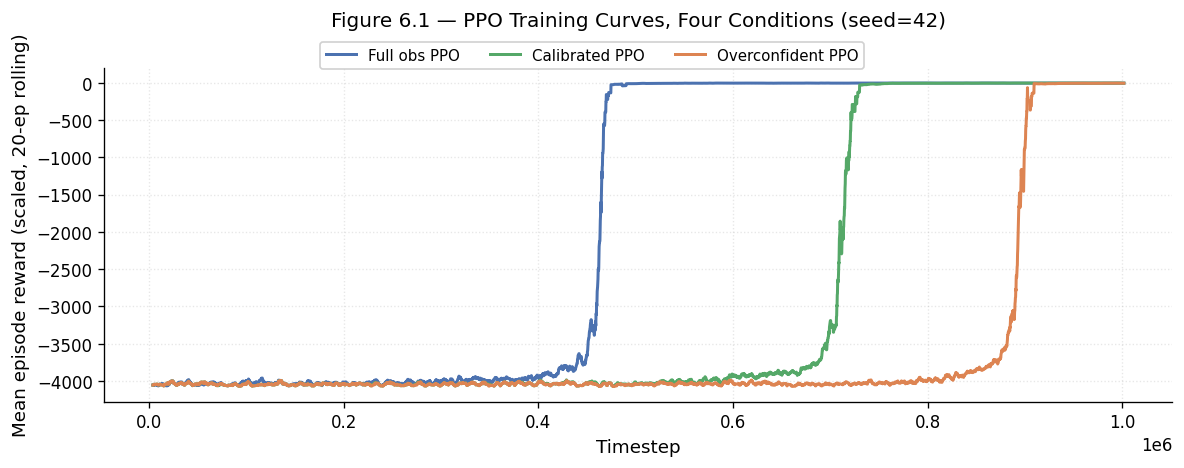

In [ ]:
# Section 6.1 — Figure 6.1: PPO Training Curves

fig, ax = plt.subplots(figsize=(10, 4))

condition_labels = {
    "full_obs_rl":         "Full obs PPO",
    "pomdp_calibrated":    "Calibrated PPO",
    "pomdp_overconfident": "Overconfident PPO",
}

for name, label in condition_labels.items():
    log_path = os.path.join(RESULTS_DIR, f"{name}_seed42", "training_log.csv")
    if os.path.exists(log_path):
        df_log = pd.read_csv(log_path)
        ax.plot(df_log["timestep"],
                df_log["mean_reward"].rolling(20).mean(),
                label=label,
                color=COLORS[label],
                lw=1.8)

ax.set_xlabel("Timestep")
ax.set_ylabel("Mean episode reward (scaled, 20-ep rolling)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           ncol=3,
           fontsize=9,
           framealpha=0.9,
           bbox_to_anchor=(0.5, 0.92))
ax.set_title("Figure 6.1 — PPO Training Curves, Four Conditions (seed=42)", pad=25)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig(os.path.join(FIGURES_DIR, "training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Asymptotic Policy Quality

The Taylor rule serves as the analytical benchmark against which all learned
policies are evaluated. Under the Taylor rule, the central bank sets the nominal
interest rate mechanically as:

$$i_t = r^n + \pi^* + \phi_\pi(\pi_t - \pi^*) + \phi_y x_t$$

with $\phi_\pi = 1.5$ and $\phi_y = 0.5$, without any learning or optimisation.
The benchmark is evaluated identically to the RL agents — across three seeds and
20 episodes per seed — to ensure like-for-like comparison. Across seeds 42, 123,
and 7, the Taylor rule achieves mean per-episode CB losses of $-9.15$, $-11.92$,
and $-12.96$ respectively, yielding a cross-seed mean of $-11.34$ (std $= 1.61$).
The relatively high variance across seeds reflects the stochastic nature of the
evaluation environment rather than any instability in the policy itself — the
Taylor rule is deterministic, so all variation comes from shock realisations.
Mean inflation across seeds remains close to the $2\%$ target (1.888–1.998\%),
the mean output gap stays near zero (0.031–0.066 pp), and the mean interest rate
tracks $i^* = 6\%$ closely (5.857–6.022\%), consistent with the attractor
displacement identified in Section 3.1.

| Condition     | Mean Reward | Std    | Gap vs Taylor |
|---------------|-------------|--------|---------------|
| Taylor Rule   | −11.3429    | 1.6078 | —             |
| Full Obs PPO   | −6.0040     | 0.5622 | 0.53×         |
| Calibrated    | −6.9478     | 1.0203 | 0.61×         |
| Overconfident | −6.0364     | 0.3308 | 0.53×         |

*Table 6.2: Multi-seed PPO Results (3 seeds, 20 episodes, ep\_len=20).
Metric: mean raw CB loss per episode, divergence excluded.*

The full-observability PPO agent achieves a cross-seed mean per-episode CB loss
of $-6.00$ (std $= 0.56$), reducing the Taylor rule loss by a factor of $0.53\times$
— roughly halving it. Per-seed results are $-5.22$, $-6.52$, and $-6.27$ for
seeds 42, 123, and 7 respectively. This improvement is achieved despite the agent
having no prior knowledge of the Taylor rule or the stability conditions of the NK
model — it learns solely from the reward signal. The full-observability result
establishes the performance ceiling under perfect state information: an upper bound
on what any PPO agent can achieve in this environment, against which the POMDP
conditions are compared.

Under partial observability, both POMDP conditions achieve welfare losses within
the range of the full-observability agent. The overconfident agent achieves a
cross-seed mean of $-6.04$ (std $= 0.33$, gap $= 0.53\times$), nearly matching
full-observability performance. The calibrated agent achieves $-6.95$
(std $= 1.02$, gap $= 0.61\times$), somewhat further from the ceiling. This
welfare ordering — overconfident performing better than calibrated on raw CB loss
— is counterintuitive given the central hypothesis and is addressed directly in
Section 7. The key observation here is that all three PPO conditions substantially
outperform the Taylor rule, with welfare losses roughly half those of the
analytical benchmark regardless of observation quality.

In [ ]:
# Section 6.2 — Table 6.2: Multi-seed PPO Results

taylor_mean = np.array(all_seed_results["taylor_rule"]).mean()

CONDITION_LABELS = {
    "taylor_rule":         "Taylor Rule",
    "full_obs_rl":         "Full Obs PPO",
    "pomdp_calibrated":    "Calibrated PPO",
    "pomdp_overconfident": "Overconfident PPO",
}

rows = []
for name in ["taylor_rule", "full_obs_rl", "pomdp_calibrated", "pomdp_overconfident"]:
    vals = np.array(all_seed_results[name])
    m, s = vals.mean(), vals.std()
    gap  = f"{m/taylor_mean:.2f}×" if name != "taylor_rule" else "—"
    rows.append({
        "Condition":     CONDITION_LABELS[name],
        "Mean reward":   f"{m:.4f}",
        "Std":           f"{s:.4f}",
        "Gap vs Taylor": gap,
    })

df_62 = pd.DataFrame(rows).set_index("Condition")
show_table(
    df_62,
    title="Table 6.2 — Multi-seed PPO Results (3 seeds, 20 episodes, ep_len=20)",
    caption="Metric: mean raw CB loss per episode, divergence excluded."
)

,Mean reward,Std,Gap vs Taylor
Condition,,,
Taylor Rule,-11.3429,1.6078,—
Full Obs PPO,-6.0040,0.5622,0.53×
Calibrated PPO,-6.9478,1.0203,0.61×
Overconfident PPO,-6.0364,0.3308,0.53×


### 6.3 Taylor Principle Compliance

The Taylor principle — the condition $\hat{\phi}_{\pi,LR} > 1$ under which a
central bank raises the real interest rate in response to inflation, ensuring a
determinate equilibrium — provides a structural benchmark against which the
learned policies can be evaluated independently of their raw welfare performance.
We test compliance by fitting an inertial OLS regression of the form:

$$\hat{i}_t = \alpha + \rho \hat{i}_{t-1} + \hat{\phi}_\pi(\hat{\mu}_{\pi,t} - \pi^*) + \hat{\phi}_y \hat{\mu}_{x,t}$$

on the deterministic evaluation trajectories of each agent, where $\hat{\mu}_{\pi,t}$
and $\hat{\mu}_{x,t}$ are the belief-state means for the POMDP conditions and the
true state for full observability. The long-run inflation response coefficient is
recovered as $\hat{\phi}_{\pi,LR} = \hat{\phi}_\pi / (1 - \rho)$, following the
standard inertial Taylor rule literature. As noted in Section 5, this regression
captures only the linear projection of the agent's policy onto the Taylor rule
basis — $\hat{\phi}_{\pi,LR} < 1$ does not imply unstable dynamics, but indicates
that the policy's stabilisation mechanism is not fully representable by a
linear-in-state rule. The within-condition $\hat{\phi}_\pi$ point estimates are
precisely estimated (all significant at the 0.1\% level, HC3 robust standard
errors), so each per-seed $\hat{\phi}_{\pi,LR}$ value reported below is a
well-identified summary of the agent's linear policy projection rather than a
noisy regression artefact. However, with only three seeds per condition we
cannot conduct formal across-condition inference on the differences in
$\hat{\phi}_{\pi,LR}$ — the calibrated-vs-overconfident comparison should be
read as suggestive of a directional effect rather than statistically
established.

The per-seed results are reported in Table 6.3. Notably, full observability also
satisfies the Taylor principle in only 1/3 seeds (seed=42, $\hat{\phi}_{\pi,LR} =
1.026$), suggesting that Taylor compliance is a demanding criterion even under
perfect state information — and that the calibrated agent matching this compliance
rate despite operating under partial observability is the more meaningful
comparison. The headline finding is a consistent directional ordering: calibrated
PPO achieves a higher mean $\hat{\phi}_{\pi,LR}$ across all three seeds (0.967)
than overconfident PPO (0.880). More strikingly, overconfident PPO never satisfies
the Taylor principle across any seed (0/3), while calibrated PPO satisfies it in
seed=42 — the only instance of any POMDP condition clearing the determinacy
threshold. This 0/3 versus 1/3 compliance split is the cleanest expression of the
central finding: belief-state calibration affects the structural properties of the
learned policy in a directionally consistent way across seeds, even when the
magnitude of the difference varies.

| Condition | seed=42 | seed=123 | seed=7 | Mean | n✓/3 |
|:---|---:|---:|---:|---:|---:|
| Full Obs PPO | 1.026 ✓ | 0.731 ✗ | 0.833 ✗ | 0.863 | 1/3 |
| Calibrated PPO | 1.151 ✓ | 0.963 ✗ | 0.788 ✗ | 0.967 | 1/3 |
| Overconfident PPO | 0.832 ✗ | 0.964 ✗ | 0.844 ✗ | 0.880 | 0/3 |

*Table 6.3: Long-run inflation response coefficient $\hat{\phi}_{\pi,LR}$ by
seed and condition. ✓ indicates Taylor principle satisfied
($\hat{\phi}_{\pi,LR} > 1$). Full regression output including $\rho$, $R^2$,
and per-seed details reported in Table 6.3b.*

The seed-level evidence is mixed in magnitude. In seed=42 the gap between
calibrated and overconfident is large (1.151 vs 0.832), driving most of the mean
difference. In seed=123 the two POMDP conditions are essentially tied (0.963 vs
0.964), and in seed=7 overconfident marginally leads (0.844 vs 0.788). The mean
ordering is therefore robust in direction but not in level — the strength of the
calibration effect varies considerably across seeds, and consistent with the
limitation flagged above, we treat the 0/3 compliance asymmetry and the
directional mean ordering as suggestive rather than conclusive evidence.

Two further observations are worth noting. First, the inertia coefficient $\rho$
is on average higher for overconfident PPO (mean 0.361, range 0.329--0.408) than
for calibrated PPO (mean 0.305, range 0.262--0.344), though the difference is
concentrated in seed=42 (0.408 vs 0.262) and the two are essentially tied in
seed=123 (0.345 vs 0.344). This suggests the overconfident agent relies more
heavily on rate smoothing relative to state-contingent adjustment — a policy
structure that can stabilise the economy in expectation while falling short of
the Taylor principle's determinacy requirement. Second, a striking pattern emerges
in $R^2$: the ordering Full Obs (0.283) $<$ Calibrated (0.365) $<$ Overconfident
(0.443) is preserved at every seed (Table 6.3b). The overconfident agent's policy
is the most linearly-explainable of the three, yet the linear rule it most
resembles fails the Taylor principle. The calibrated agent's policy is less
well-described by a linear-in-state rule, but the linear projection that does
describe it sits closer to Taylor compliance. This is a quantitative complement
to the headline $\hat{\phi}_{\pi,LR}$ ordering: calibration appears to push the
agent toward a less linearly-tractable policy whose linear shadow nonetheless
satisfies the structural criterion more closely. The substantial unexplained
variance is consistent with the nonlinear structures visible in the surface plots
of Section 6.8.

The 0/3 compliance asymmetry is directly consistent with the impulse-response
behaviour documented in Section 6.7, where calibrated PPO's inflation response
overshoots the target slightly while overconfident PPO undershoots — a mechanistic
signature of the $\hat{\phi}_{\pi,LR}$ ordering. That the calibrated agent is the
only POMDP condition to ever satisfy the Taylor principle, despite operating under
greater observation uncertainty, supports the interpretation developed in Section
7: calibration quality shapes the *kind* of policy learned, not merely its welfare
level.

In [ ]:
# Section 6.3 — Table 6.3: Taylor Principle Compliance Per Seed

tp_rows = []
for name in ["full_obs_rl", "pomdp_calibrated", "pomdp_overconfident"]:
    vals_lr  = []
    vals_rho = []
    vals_r2  = []

    for s in SEEDS:
        if (s, name) not in regression_results:
            continue
        res = regression_results[(s, name)]
        vals_lr.append(res["phi_pi_lr"])
        vals_rho.append(res["rho"])
        vals_r2.append(res["r2"])

    tp_rows.append({
        "Condition": CONDITION_LABELS[name],
        "seed=42 φ̂_π_LR": f"{vals_lr[0]:.3f} {'✓' if vals_lr[0]>1 else '✗'}",
        "seed=123 φ̂_π_LR": f"{vals_lr[1]:.3f} {'✓' if vals_lr[1]>1 else '✗'}",
        "seed=7 φ̂_π_LR":  f"{vals_lr[2]:.3f} {'✓' if vals_lr[2]>1 else '✗'}",
        "Mean φ̂_π_LR":    f"{np.nanmean(vals_lr):.3f}",
        "n✓/3":            f"{sum(1 for v in vals_lr if v>1)}/3",
        "Mean ρ":          f"{np.nanmean(vals_rho):.3f}",
        "Mean R²":         f"{np.nanmean(vals_r2):.3f}",
    })

df_63 = pd.DataFrame(tp_rows).set_index("Condition")
show_table(
    df_63,
    title="Table 6.3a — Taylor Principle Compliance: "
          "φ̂<sub>π,LR</sub> Per Seed",
    caption="Inertial spec: î_t = α + ρ·î_{t-1} + φ̂_π(μ̂_π − π*) + φ̂_y·μ̂_x. "
            "HC3 robust SEs. All p-values < 0.001. "
            "φ̂_π_LR = φ̂_π / (1 − ρ). Taylor principle satisfied if φ̂_π_LR > 1."
)

# Detailed per-seed breakdown (full regression output)

detail_rows = []
for name in ["full_obs_rl", "pomdp_calibrated", "pomdp_overconfident"]:
    for s in SEEDS:
        if (s, name) not in regression_results:
            continue
        res = regression_results[(s, name)]
        detail_rows.append({
            "Condition":  CONDITION_LABELS[name],
            "Seed":       s,
            "ρ":          f"{res['rho']:.3f}",
            "φ̂_π":       f"{res['phi_pi']:.3f}",
            "φ̂_π_LR":   f"{res['phi_pi_lr']:.3f} {'✓' if res['phi_pi_lr']>1 else '✗'}",
            "φ̂_y_LR":   f"{res['phi_y_lr']:.3f}",
            "R²":         f"{res['r2']:.3f}",
            "p-val":  f"{res['p']:.3f}"
        })

df_63_detail = pd.DataFrame(detail_rows).set_index(["Condition", "Seed"])
show_table(
    df_63_detail,
    title="Table 6.3b — Full Regression Output Per Seed",
    caption="Note: R² increases from Full Obs PPO → Calibrated PPO → Overconfident PPO "
            "at every seed — overconfident learns a more linearly-explainable rule "
            "that nonetheless fails the Taylor principle."
)

,seed=42 φ̂_π_LR,seed=123 φ̂_π_LR,seed=7 φ̂_π_LR,Mean φ̂_π_LR,n✓/3,Mean ρ,Mean R²
Condition,,,,,,,
Full Obs PPO,1.026 ✓,0.731 ✗,0.833 ✗,0.863,1/3,0.166,0.283
Calibrated PPO,1.151 ✓,0.963 ✗,0.788 ✗,0.967,1/3,0.305,0.365
Overconfident PPO,0.832 ✗,0.964 ✗,0.844 ✗,0.880,0/3,0.361,0.443


### 6.4 Episode Length Robustness

The primary results in Sections 6.2 and 6.3 are evaluated at episode length
$T=20$, matching the training environment. To assess whether the headline
findings are sensitive to this choice, we re-evaluate all three trained
conditions (seed=42) at $T \in \{20, 50, 100\}$ without retraining — the
same saved models are evaluated in environments with longer episode horizons.

| Condition | ep=20 | ep=50 | ep=100 |
|:---|---:|---:|---:|
| Full Obs PPO | 1.026 ✓ (R²=0.397) | 0.890 ✗ (R²=0.312) | 0.850 ✗ (R²=0.318) |
| Calibrated PPO | 1.151 ✓ (R²=0.461) | 1.011 ✓ (R²=0.383) | 0.966 ✗ (R²=0.391) |
| Overconfident PPO | 0.832 ✗ (R²=0.593) | 0.749 ✗ (R²=0.534) | 0.723 ✗ (R²=0.548) |

*Table 6.4a: $\hat{\phi}_{\pi,LR}$ and $R^2$ across episode lengths
(seed=42, inertial regression). ✓ indicates Taylor principle satisfied
($\hat{\phi}_{\pi,LR} > 1$). Full regression output reported in Table 6.4b.*

Two findings emerge. First, $\hat{\phi}_{\pi,LR}$ declines with episode
length for all conditions. This is expected: policies trained on $T=20$
episodes are optimised for short-horizon stabilisation, and longer episodes
accumulate shock realisations that push the state further from the attractor,
reducing the linear regression's explanatory power — the $R^2$ values in
Table 6.4a fall from 0.397 at $T=20$ to 0.312 at $T=50$ for full obs PPO,
with a marginal recovery to 0.318 at $T=100$, consistent with the nonlinear
policy structures documented in Section 6.8. The absolute level of
$\hat{\phi}_{\pi,LR}$ is therefore sensitive to episode length and should
not be over-interpreted.

Second, and more importantly, the calibrated ordering is robust across all
three episode lengths. Calibrated PPO has the highest $\hat{\phi}_{\pi,LR}$
at every value of $T$ tested, is the only condition satisfying the Taylor
principle at $T=50$ ($\hat{\phi}_{\pi,LR} = 1.011$), and remains the least
non-compliant at $T=100$ ($\hat{\phi}_{\pi,LR} = 0.966$). Overconfident PPO
has the lowest $\hat{\phi}_{\pi,LR}$ at every episode length. The ordering
calibrated $>$ full obs $>$ overconfident is perfectly preserved across all
three values of $T$, providing stronger evidence for the directional claim
in Section 6.3 than the multi-seed analysis alone: the calibration effect on
policy structure is robust to episode length even when it is not fully robust
to seed choice.

On welfare, the ordering is similarly stable: PPO conditions achieve
approximately $0.53\times$ the Taylor rule loss at $T=20$, scaling
proportionally at $T=50$ and $T=100$ with no evidence of degradation at
longer horizons.

,ep=20,ep=50,ep=100
Condition,,,
Full obs PPO,1.026 ✓ (R²=0.397),0.890 ✗ (R²=0.312),0.850 ✗ (R²=0.318)
Calibrated PPO,1.151 ✓ (R²=0.461),1.011 ✓ (R²=0.383),0.966 ✗ (R²=0.391)
Overconfident PPO,0.832 ✗ (R²=0.593),0.749 ✗ (R²=0.534),0.723 ✗ (R²=0.548)


,ep=20,ep=50,ep=100
Condition,,,
Taylor rule,-9.1503,-24.4713,-54.8498
Full obs PPO,-5.2226,-13.4734,-29.8303
Calibrated PPO,-8.3899,-20.9304,-45.3433
Overconfident PPO,-5.6010,-14.2123,-31.2067


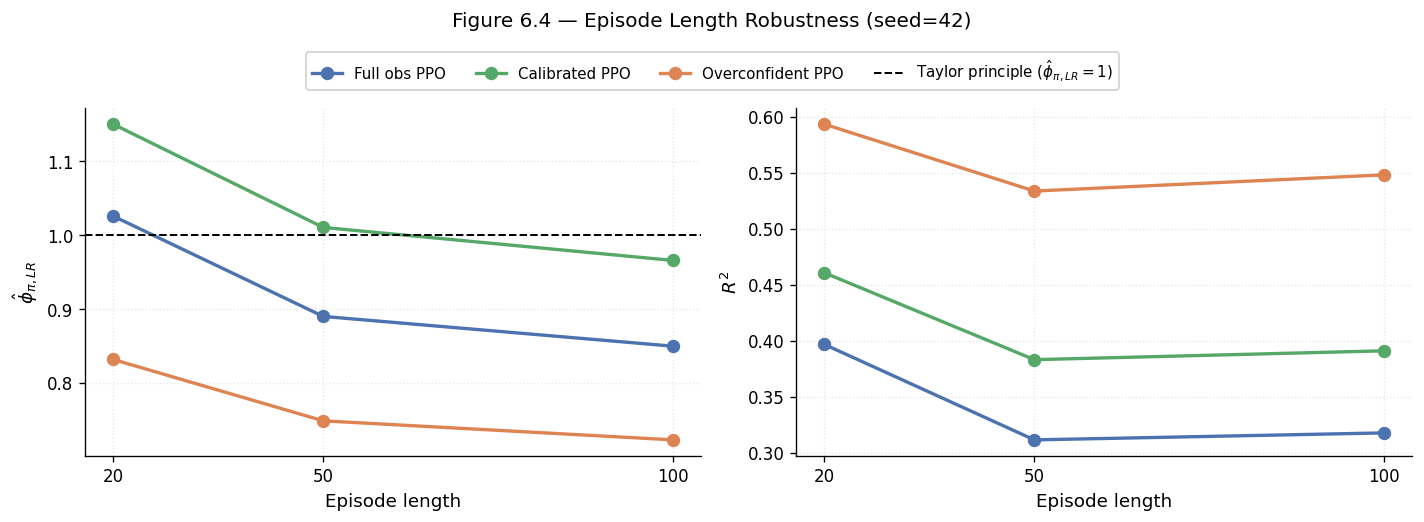

Robustness check complete.


In [ ]:
# =============================================================================
# Episode Length Robustness Cell — Section 6.4
# =============================================================================
# Re-evaluates saved seed=42 models at ep_len = 20, 50, 100 to test whether
# the Taylor principle compliance result is robust to episode length.
# No retraining — loads from saved model.zip files.
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

EP_LENS      = [20, 50, 100]
EVAL_EPS_ROB = 20
RUN_SEED     = 42
I_STEADY     = NKEnv.R_N + NKEnv.PI_STAR


def evaluate_ep_len(model_or_none, condition_name, ep_len, seed=42):
    pi_all, x_all, i_all, r_all = [], [], [], []
    mu_pi_all, mu_x_all = [], []

    if condition_name == "taylor_rule":
        env = NKEnv(mode='full_obs', ep_len=ep_len, seed=seed)
        for ep in range(EVAL_EPS_ROB):
            obs, _ = env.reset(seed=seed + ep)
            done = False
            while not done:
                i_t = env.taylor_action(clip=False)
                obs, _, term, trunc, info = env.step(np.array([i_t]))
                pi_all.append(info["pi"]);    x_all.append(info["x"])
                i_all.append(i_t);            r_all.append(info["reward"])
                mu_pi_all.append(info["pi"]); mu_x_all.append(info["x"])
                done = term or trunc
    else:
        if "calibrated" in condition_name and "over" not in condition_name:
            loader = PlaceholderLoader(
                sigma_pi=SIGMA_PI_CALIB, sigma_x=SIGMA_X_CALIB,
                noise_scale=0.01, seed=seed + 1)
            mode = 'pomdp_calibrated'
        elif "overconf" in condition_name:
            loader = PlaceholderLoader(
                sigma_pi=SIGMA_PI_OVERC, sigma_x=SIGMA_X_OVERC,
                noise_scale=0.01, seed=seed + 1)
            mode = 'pomdp_overconf'
        else:
            loader, mode = None, 'full_obs'

        env = NKEnv(mode=mode, ep_len=ep_len, seed=seed, loader=loader)
        for ep in range(EVAL_EPS_ROB):
            obs, _ = env.reset(seed=seed + ep)
            done = False
            while not done:
                action, _ = model_or_none.predict(obs, deterministic=True)
                obs, _, term, trunc, info = env.step(action)
                pi_all.append(info["pi"]);  x_all.append(info["x"])
                i_all.append(info["i"]);    r_all.append(info["reward"])
                if mode != 'full_obs' and loader is not None:
                    belief = loader.get(env._t - 1, info["pi"], info["x"])
                    mu_pi_all.append(float(belief[0]))
                    mu_x_all.append(float(belief[2]))
                else:
                    mu_pi_all.append(info["pi"])
                    mu_x_all.append(info["x"])
                done = term or trunc

    i_arr = np.array(i_all)
    n     = len(i_arr)
    i_lag = np.empty_like(i_arr)
    for ep_start in range(0, n, ep_len):
        i_lag[ep_start] = I_STEADY
        ep_end = min(ep_start + ep_len, n)
        i_lag[ep_start + 1:ep_end] = i_arr[ep_start:ep_end - 1]

    return (np.array(pi_all), np.array(x_all), i_arr,
            i_lag, np.array(r_all),
            np.array(mu_pi_all), np.array(mu_x_all))


def run_inertial_regression(pi, x, i, i_lag, mu_pi, mu_x, condition_name):
    pi_input = (pi - NKEnv.PI_STAR if condition_name == "full_obs_rl"
                else mu_pi - NKEnv.PI_STAR)
    x_input  = x if condition_name == "full_obs_rl" else mu_x
    X_reg    = add_constant(np.column_stack([i_lag, pi_input, x_input]))
    ols      = OLS(i, X_reg).fit(cov_type="HC3")
    rho      = ols.params[1]
    phi_pi   = ols.params[2]
    phi_y    = ols.params[3]
    denom    = (1 - rho) if abs(1 - rho) > 0.01 else np.nan
    return rho, phi_pi, phi_pi / denom, phi_y, phi_y / denom, ols.rsquared

# Load seed=42 models

model_full = PPO.load(
    os.path.join(RESULTS_DIR, "full_obs_rl_seed42", "model.zip"),
    env=DummyVecEnv([lambda: NKEnv(mode='full_obs', ep_len=20, seed=SEED)]))

_loader_c = PlaceholderLoader(
    sigma_pi=SIGMA_PI_CALIB, sigma_x=SIGMA_X_CALIB,
    noise_scale=0.01, seed=SEED)
model_calib = PPO.load(
    os.path.join(RESULTS_DIR, "pomdp_calibrated_seed42", "model.zip"),
    env=DummyVecEnv([lambda: NKEnv(mode='pomdp_calibrated', ep_len=20,
                                   seed=SEED, loader=_loader_c)]))

_loader_o = PlaceholderLoader(
    sigma_pi=SIGMA_PI_OVERC, sigma_x=SIGMA_X_OVERC,
    noise_scale=0.01, seed=SEED)
model_overc = PPO.load(
    os.path.join(RESULTS_DIR, "pomdp_overconfident_seed42", "model.zip"),
    env=DummyVecEnv([lambda: NKEnv(mode='pomdp_overconf', ep_len=20,
                                   seed=SEED, loader=_loader_o)]))

named_models = [
    ("full_obs_rl",         model_full),
    ("pomdp_calibrated",    model_calib),
    ("pomdp_overconfident", model_overc),
]

condition_labels = {
    "full_obs_rl":         "Full obs PPO",
    "pomdp_calibrated":    "Calibrated PPO",
    "pomdp_overconfident": "Overconfident PPO",
}

# Run robustness check

rob_results = {
    name: {"ep_lens": [], "phi_pi_lr": [], "rho": [], "r2": []}
    for name, _ in named_models
}
rob_rewards = {name: [] for name, _ in named_models}
rob_rewards["taylor_rule"] = []

for ep_len in EP_LENS:
    for name, model in named_models:
        pi, x, i, i_lag, r, mu_pi, mu_x = evaluate_ep_len(
            model, name, ep_len=ep_len, seed=RUN_SEED)
        rho, phi_pi, phi_pi_lr, phi_y, phi_y_lr, r2 = run_inertial_regression(
            pi, x, i, i_lag, mu_pi, mu_x, name)
        rob_results[name]["ep_lens"].append(ep_len)
        rob_results[name]["phi_pi_lr"].append(phi_pi_lr)
        rob_results[name]["rho"].append(rho)
        rob_results[name]["r2"].append(r2)
        rob_rewards[name].append(r.sum() / EVAL_EPS_ROB)

    pi_t, x_t, i_t, i_lag_t, r_t, _, _ = evaluate_ep_len(
        None, "taylor_rule", ep_len=ep_len, seed=RUN_SEED)
    rob_rewards["taylor_rule"].append(r_t.sum() / EVAL_EPS_ROB)

# Table 6.4a — Taylor principle compliance by episode length

tp_rob_rows = []
for name, _ in named_models:
    row = {"Condition": condition_labels[name]}
    for idx, ep_len in enumerate(EP_LENS):
        phi = rob_results[name]["phi_pi_lr"][idx]
        r2  = rob_results[name]["r2"][idx]
        row[f"ep={ep_len}"] = f"{phi:.3f} {'✓' if phi>1 else '✗'} (R²={r2:.3f})"
    tp_rob_rows.append(row)

df_64a = pd.DataFrame(tp_rob_rows).set_index("Condition")
show_table(
    df_64a,
    title="Table 6.4a — φ̂<sub>π,LR</sub> and R² Across Episode Lengths (seed=42)"
)

# Table 6.4b — Mean reward by episode length

rew_rows = []
for name in ["taylor_rule"] + [n for n, _ in named_models]:
    label = condition_labels.get(name, "Taylor rule")
    row   = {"Condition": label}
    for idx, ep_len in enumerate(EP_LENS):
        row[f"ep={ep_len}"] = f"{rob_rewards[name][idx]:.4f}"
    rew_rows.append(row)

df_64b = pd.DataFrame(rew_rows).set_index("Condition")
show_table(
    df_64b,
    title="Table 6.4b — Mean Raw CB Loss by Episode Length (seed=42)"
)


# Figure 6.4 — phi_pi_LR and R2 vs episode length

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for name, _ in named_models:
    ax.plot(rob_results[name]["ep_lens"],
            rob_results[name]["phi_pi_lr"],
            "o-", color=COLORS[condition_labels[name]],
            lw=2, markersize=7, label=condition_labels[name])
ax.axhline(1.0, color="black", lw=1.2, ls="--",
           label=r"Taylor principle ($\hat{\phi}_{\pi,LR}=1$)")
ax.set_xlabel("Episode length")
ax.set_ylabel(r"$\hat{\phi}_{\pi,LR}$")
ax.set_xticks(EP_LENS)
ax.legend(fontsize=8)

ax = axes[1]
for name, _ in named_models:
    ax.plot(rob_results[name]["ep_lens"],
            rob_results[name]["r2"],
            "o-", color=COLORS[condition_labels[name]],
            lw=2, markersize=7, label=condition_labels[name])
ax.set_xlabel("Episode length")
ax.set_ylabel(r"$R^2$")
ax.set_xticks(EP_LENS)
ax.legend(fontsize=8)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center", ncol=4, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, 1.01))
axes[0].get_legend().remove()
axes[1].get_legend().remove()
fig.suptitle("Figure 6.4 — Episode Length Robustness (seed=42)", y=1.08, fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ep_len_robustness.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Robustness check complete.")

### 6.5 Alternative Environment Robustness Check

Before turning to the calibration comparison, we verify that the headline PPO
advantage over the Taylor rule is not an artefact of the primary environment's
specific parameterisation. The alternative environment differs from the primary
NKEnv in four ways: it uses decimal units ($\pi^* = 0.02$, $r^* = 0.01$)
rather than annualised percentage points; it adopts anchored expectations with
$\rho_\pi = 0.7$ rather than hybrid expectations with $\omega = 0.7$; it uses
episode length 200 rather than 20; and it replaces the divergence penalty with
an interest-rate smoothing penalty $\omega_s(i_t - i_{t-1})^2$ with weight
$\omega_s = 0.1$. The Phillips curve slope is also recalibrated to $\kappa = 0.20$,
reflecting a more flexible price-setting environment. These differences together
produce a substantially different reward scale, making direct welfare comparison
impossible — the robustness check is therefore conducted on the *percentage
improvement* of PPO over the Taylor rule rather than on absolute loss levels.
The alternative-environment PPO agent is trained under full observability (true
state $(\pi_t, x_t, i_{t-1})$ as input), matching the full-observability condition
in the primary environment. This ensures the $+48.3\%$ and $+47.1\%$ improvements
are computed under directly comparable observation regimes — the robustness check
tests cross-environment stability of the PPO advantage holding the observation
regime fixed at full obs.

The alternative environment PPO agent (pre-trained for 200,000 timesteps in a separate script and loaded here as `models/ppo_nk_step5_rescale`) was evaluated over 50 episodes. The Taylor rule achieves a mean per-episode reward
of $-0.2034$ (std $= 0.026$); PPO achieves $-0.1051$ (std $= 0.011$),
corresponding to a welfare improvement of $+48.3\%$. This is nearly identical
to the primary result, where full-observability PPO improves on the Taylor rule
by $+47.1\%$ in the annualised percentage point environment. The two
specifications, despite differing in units, expectations formation, episode
length, and penalty structure, produce PPO improvements within 1.2 percentage
points of each other.

| Environment                              | Policy       | Mean Reward | Std    | PPO Improvement |
|------------------------------------------|--------------|-------------|--------|-----------------|
| Primary (annualised %, ep=20, 3 seeds)   | Taylor rule  | −11.3429    | 1.6078 | —               |
| Primary (annualised %, ep=20, 3 seeds)   | Full Obs PPO | −6.0040     | 0.5622 | +47.1%          |
| Alternative (decimal, ep=200, smoothing) | Taylor rule  | −0.2034     | 0.0259 | —               |
| Alternative (decimal, ep=200, smoothing) | Full Obs PPO | −0.1051     | 0.0110 | +48.3%          |

*Table 6.5: Cross-specification robustness check. PPO improvement computed as
(PPO − Taylor) / |Taylor| × 100%. Both PPO rows are full-observability conditions.*

This consistency provides evidence that the headline PPO advantage is not an
artefact of any particular implementation choice — the NK model structure and
the PPO reward signal are sufficient to produce robust improvements over the
analytical benchmark regardless of parameterisation. PPO also reduces evaluation
variance relative to the Taylor rule in both specifications (std $= 0.5622$ vs
$1.6078$ in the primary env; std $= 0.011$ vs $0.026$ in the alternative),
suggesting that learned policies are more robust to shock realisations than the
mechanical rule across both specifications. We do not replicate the
calibrated/overconfident POMDP contrast in the alternative environment — the
robustness check is scoped to the headline PPO-over-Taylor improvement, not to
the calibration comparison itself. Cross-environment robustness of the calibration
finding is left for future work.

In [ ]:
# =============================================================================
# Robustness check: PPO improvement in alternative env spec
# =============================================================================
# This section verifies that the headline PPO improvement over the Taylor rule
# is not an artefact of the annualised-% NKEnv specification.
# We re-run the same training-evaluation comparison in an independent
# implementation with different parameters: decimal units, episode length 200,
# anchored expectations (rho_pi=0.7), and an interest-rate smoothing penalty
# replacing the divergence penalty.
#
# The trained PPO model and the alternative env are pre-saved; this cell
# loads, evaluates, and reports.
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

from gymnasium.wrappers import RescaleAction
# -----------------------------------------------------------------------------
# Alternative environment specification (decimal units)
# -----------------------------------------------------------------------------
# Differs from the previous NKEnv in four ways:
#   1. Decimal units (pi* = 0.02 vs 2.0; r* = 0.01 vs 4.0; i_max = 0.20 vs 20.0)
#   2. Anchored expectations: pi_{t+1} = pi* + rho_pi*(pi_t - pi*) + kappa*x_{t+1}
#      vs NKEnv's hybrid expectations with beta < 1
#   3. Episode length 200 (vs 20)
#   4. Smoothing penalty omega*(i_t - i_{t-1})^2 (vs divergence penalty)
# These together produce a substantially different reward magnitude scale.

class _NKAltEnv(gym.Env):
    """Alternative-spec NK Gym env for robustness check."""
    metadata = {"render_modes": []}

    SIGMA   = 1.0;   KAPPA   = 0.2;    RHO_PI  = 0.7
    PI_STAR = 0.02;  R_STAR  = 0.01
    PHI_PI  = 1.5;   PHI_Y   = 0.5;    LAM     = 1.0
    I_MIN   = 0.0;   I_MAX   = 0.20
    RHO_D   = 0.5;   RHO_S   = 0.5
    SIGMA_D = 0.01;  SIGMA_S = 0.008
    OMEGA   = 0.1     # smoothing penalty weight

    def __init__(self, n_periods=200):
        super().__init__()
        self.n_periods = n_periods
        self.observation_space = spaces.Box(
            low=np.array([-0.20, -0.50, self.I_MIN], dtype=np.float32),
            high=np.array([0.20, 0.50, self.I_MAX], dtype=np.float32),
            dtype=np.float32)
        self.action_space = spaces.Box(
            low=np.array([self.I_MIN], dtype=np.float32),
            high=np.array([self.I_MAX], dtype=np.float32),
            dtype=np.float32)

    @property
    def i_star(self):
        return self.R_STAR + self.PI_STAR

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            np.random.seed(seed)
        self.pi    = self.PI_STAR
        self.x     = 0.0
        self.i     = self.i_star
        self.eps_d = 0.0
        self.eps_s = 0.0
        self.t     = 0
        return np.array([self.pi, self.x, self.i], dtype=np.float32), {}

    def step(self, action):
        i_t = float(np.clip(np.asarray(action).item(), self.I_MIN, self.I_MAX))
        eps_d_new = self.RHO_D * self.eps_d + self.SIGMA_D * np.random.randn()
        eps_s_new = self.RHO_S * self.eps_s + self.SIGMA_S * np.random.randn()

        x_new  = self.x - self.SIGMA * (i_t - self.PI_STAR - self.R_STAR) + eps_d_new
        pi_new = (self.PI_STAR
                  + self.RHO_PI * (self.pi - self.PI_STAR)
                  + self.KAPPA * x_new
                  + eps_s_new)

        smoothing_pen = self.OMEGA * (i_t - self.i) ** 2
        loss   = (pi_new - self.PI_STAR)**2 + self.LAM * x_new**2
        reward = -(loss + smoothing_pen)

        self.pi, self.x, self.i = pi_new, x_new, i_t
        self.eps_d, self.eps_s = eps_d_new, eps_s_new
        self.t += 1

        truncated = self.t >= self.n_periods
        info = {"pi": self.pi, "x": self.x, "i": i_t}
        return np.array([self.pi, self.x, self.i], dtype=np.float32), \
               reward, False, truncated, info

    def taylor_rule_action(self):
        i_t = (self.R_STAR + self.PI_STAR
               + self.PHI_PI * (self.pi - self.PI_STAR)
               + self.PHI_Y  * self.x)
        return np.array([np.clip(i_t, self.I_MIN, self.I_MAX)],
                        dtype=np.float32)


# -----------------------------------------------------------------------------
# Evaluate Taylor rule and PPO in the alternative env (50 episodes each)
# -----------------------------------------------------------------------------
N_EPS_ROB     = 50
N_PERIODS_ROB = 200

def _eval_alt(use_ppo, ppo_model=None, seed=0):
    rewards = []
    for ep in range(N_EPS_ROB):
        env = RescaleAction(_NKAltEnv(n_periods=N_PERIODS_ROB),
                            min_action=-1.0, max_action=1.0)
        obs, _ = env.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            if use_ppo:
                action, _ = ppo_model.predict(obs, deterministic=True)
            else:
                raw = float(env.env.taylor_rule_action()[0])
                a   = 2*(raw - _NKAltEnv.I_MIN)/(_NKAltEnv.I_MAX - _NKAltEnv.I_MIN) - 1
                action = np.array([a], dtype=np.float32)
            obs, r, term, trunc, _ = env.step(action)
            total += r
            done = term or trunc
        rewards.append(total)
    return np.array(rewards)


ppo_alt = PPO.load("models/ppo_nk_step5_rescale")
taylor_rewards_alt = _eval_alt(use_ppo=False, seed=0)
ppo_rewards_alt    = _eval_alt(use_ppo=True, ppo_model=ppo_alt, seed=0)

# Table 6.5 — Robustness check results

TAYLOR_PRIMARY  = np.mean(all_seed_results["taylor_rule"])
FULLOBS_PRIMARY = np.mean(all_seed_results["full_obs_rl"])
improvement_primary = (FULLOBS_PRIMARY - TAYLOR_PRIMARY) / abs(TAYLOR_PRIMARY) * 100
improvement_alt     = (ppo_rewards_alt.mean() - taylor_rewards_alt.mean()) / abs(taylor_rewards_alt.mean()) * 100

rob_rows = [
    {
        "Environment":    "Primary (annualised %, ep=20, 3 seeds)",
        "Policy":         "Taylor rule",
        "Mean reward":    f"{TAYLOR_PRIMARY:.4f}",
        "Std":            f"{np.std(all_seed_results['taylor_rule']):.4f}",
        "PPO improvement": "—",
    },
    {
        "Environment":    "Primary (annualised %, ep=20, 3 seeds)",
        "Policy":         "Full obs PPO",
        "Mean reward":    f"{FULLOBS_PRIMARY:.4f}",
        "Std":            f"{np.std(all_seed_results['full_obs_rl']):.4f}",
        "PPO improvement": f"{improvement_primary:+.1f}%",
    },
    {
        "Environment":    "Alternative (decimal, ep=200, smoothing)",
        "Policy":         "Taylor rule",
        "Mean reward":    f"{taylor_rewards_alt.mean():.4f}",
        "Std":            f"{taylor_rewards_alt.std():.4f}",
        "PPO improvement": "—",
    },
    {
        "Environment":    "Alternative (decimal, ep=200, smoothing)",
        "Policy":         "PPO",
        "Mean reward":    f"{ppo_rewards_alt.mean():.4f}",
        "Std":            f"{ppo_rewards_alt.std():.4f}",
        "PPO improvement": f"{improvement_alt:+.1f}%",
    },
]

df_65 = pd.DataFrame(rob_rows).set_index(["Environment", "Policy"])
show_table(
    df_65,
    title="Table 6.5 — Cross-Specification Robustness Check",
    caption="PPO improvement computed as (PPO − Taylor) / |Taylor| × 100%."
)

### 6.6 Algorithm Comparison: SAC vs PPO

As a methodological cross-check, we train a Soft Actor-Critic (SAC) agent on both POMDP conditions using the same belief-state specification as PPO. SAC is an off-policy, entropy-regularised algorithm that maximises a trade-off between expected reward and policy entropy, maintaining exploration throughout training. Chen et al. (2025) use SAC for a related deep-RL monetary-policy application in their Bank of England staff working paper, making this a natural comparison point on the algorithm-choice axis.

**Convergence speed.** The training curves show SAC converging to its asymptotic reward in approximately 10,000 timesteps for both POMDP conditions — roughly 50–90× faster than the equivalent PPO runs (450k–900k timesteps). This is consistent with SAC's off-policy sample efficiency advantage.

**Asymptotic welfare.** SAC achieves slightly worse mean reward than PPO across both conditions (calibrated: $-9.80$ vs $-6.95$; overconfident: $-9.56$ vs $-6.04$). The sample efficiency advantage comes at a modest asymptotic performance cost, consistent with the broader RL literature on the PPO/SAC trade-off.

**Taylor principle compliance.** The per-seed SAC results (Table 6.6a) show that overconfident SAC satisfies the Taylor principle in all three seeds ($\hat{\phi}_{\pi,LR} = 1.285, 1.114, 1.119$, mean $1.173$, $3/3$ seeds). Calibrated SAC satisfies in 2 out of 3 seeds ($1.361, 0.972, 1.172$, mean $1.169$), with seed=123 the single exception. This is a notable contrast with PPO, where overconfident consistently fails to satisfy the principle (mean $\hat{\phi}_{\pi,LR} = 0.880$, $0/3$ seeds). The overconfident policy collapse observed under PPO is therefore not an inevitable consequence of overconfident belief states — SAC's entropy regularisation maintains sufficient exploration to prevent premature commitment to a non-compliant policy. The full results are presented in Tables 6.6a and 6.6b below.


############################################################
  SAC  SEED = 42
############################################################

  Condition: pomdp_calibrated  (seed=42)
  Loading saved model from results_sac/pomdp_calibrated_seed42/model.zip
  Eval — mean ep reward: -9.0624  pi: 2.026%  x: 0.261pp  i: 6.028%

  Condition: pomdp_overconfident  (seed=42)
  Loading saved model from results_sac/pomdp_overconfident_seed42/model.zip
  Eval — mean ep reward: -7.6447  pi: 2.014%  x: 0.175pp  i: 6.023%

############################################################
  SAC  SEED = 123
############################################################

  Condition: pomdp_calibrated  (seed=123)
  Loading saved model from results_sac/pomdp_calibrated_seed123/model.zip
  Eval — mean ep reward: -9.8416  pi: 1.923%  x: 0.286pp  i: 5.877%

  Condition: pomdp_overconfident  (seed=123)
  Loading saved model from results_sac/pomdp_overconfident_seed123/model.zip
  Eval — mean ep reward: -10.9810  pi: 

,seed=42,seed=123,seed=7,Mean,n✓/3
Condition,,,,,
Calibrated,1.361 ✓,0.972 ✗,1.172 ✓,1.169,2/3
Overconfident,1.285 ✓,1.114 ✓,1.119 ✓,1.173,3/3


,,Mean reward,Std,"φ̂π,LR",Satisfies
Condition,Algorithm,,,,
Taylor Rule,PPO,-11.3429,1.6078,—,—
Full Obs,PPO,-6.0040,0.5622,0.863,✗
Calibrated,PPO,-6.9478,1.0203,0.967,✗
Overconfident,PPO,-6.0364,0.3308,0.880,✗
Calibrated,SAC,-9.8024,0.5889,1.169,✓
Overconfident,SAC,-9.5583,1.4056,1.173,✓


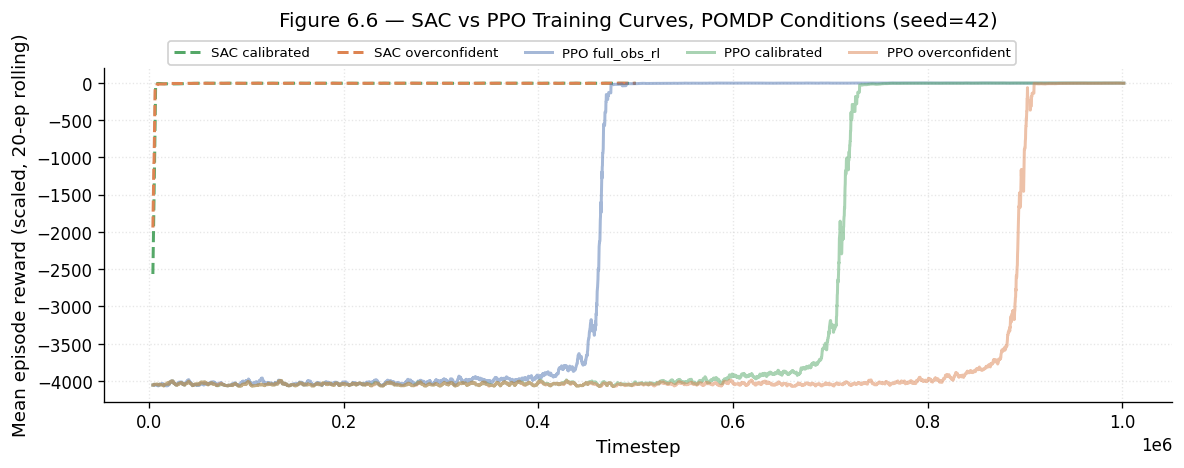

In [ ]:
# SAC vs PPO Cell — POMDP conditions only — Section 6.6

import warnings
warnings.filterwarnings("ignore")

from stable_baselines3 import SAC

SAC_TOTAL_STEPS = 500_000
SAC_SEEDS       = [42, 123, 7]
RESULTS_DIR_SAC = "results_sac"
os.makedirs(RESULTS_DIR_SAC, exist_ok=True)

SAC_KWARGS = dict(
    learning_rate  = 3e-4,
    buffer_size    = 100_000,
    learning_starts= 1_000,
    batch_size     = 256,
    tau            = 0.005,
    gamma          = 0.99,
    train_freq     = 1,
    gradient_steps = 1,
    ent_coef       = "auto",
    policy_kwargs  = dict(net_arch=[64, 64]),
    verbose        = 0,
)


class SACEpisodeLogCallback(BaseCallback):
    def __init__(self, log_freq=10):
        super().__init__()
        self.log_freq  = log_freq
        self.records   = []
        self._ep_count = 0

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self._ep_count += 1
                if self._ep_count % self.log_freq == 0:
                    self.records.append({
                        "episode":     self._ep_count,
                        "mean_reward": info["episode"]["r"],
                        "timestep":    self.num_timesteps,
                    })
        return True

    def as_dataframe(self):
        return pd.DataFrame(self.records)


def evaluate_sac(model, condition_name, seed=42):
    pi_all, x_all, i_all, r_all = [], [], [], []
    mu_pi_all, mu_x_all         = [], []

    if "calibrated" in condition_name and "over" not in condition_name:
        loader = PlaceholderLoader(
            sigma_pi=SIGMA_PI_CALIB, sigma_x=SIGMA_X_CALIB,
            noise_scale=0.01, seed=seed + 1)
        mode = 'pomdp_calibrated'
    else:
        loader = PlaceholderLoader(
            sigma_pi=SIGMA_PI_OVERC, sigma_x=SIGMA_X_OVERC,
            noise_scale=0.01, seed=seed + 1)
        mode = 'pomdp_overconf'

    env = NKEnv(mode=mode, ep_len=20, seed=seed, loader=loader)
    for ep in range(EVAL_EPISODES):
        obs, _ = env.reset(seed=seed + ep)
        done   = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, term, trunc, info = env.step(action)
            pi_all.append(info["pi"])
            x_all.append(info["x"])
            i_all.append(info["i"])
            r_all.append(info["reward"])
            belief = loader.get(env._t - 1, info["pi"], info["x"])
            mu_pi_all.append(float(belief[0]))
            mu_x_all.append(float(belief[2]))
            done = term or trunc

    i_arr    = np.array(i_all)
    n        = len(i_arr)
    ep_len   = 20
    i_lag    = np.empty_like(i_arr)
    I_STEADY = NKEnv.R_N + NKEnv.PI_STAR
    for ep_start in range(0, n, ep_len):
        i_lag[ep_start] = I_STEADY
        ep_end = min(ep_start + ep_len, n)
        i_lag[ep_start + 1:ep_end] = i_arr[ep_start:ep_end - 1]

    return (np.array(pi_all), np.array(x_all), i_arr,
            i_lag, np.array(r_all),
            np.array(mu_pi_all), np.array(mu_x_all))


def inertial_regression_sac(pi, x, i, i_lag, mu_pi, mu_x):
    pi_input = mu_pi - NKEnv.PI_STAR
    x_input  = mu_x
    X_reg    = add_constant(np.column_stack([i_lag, pi_input, x_input]))
    ols      = OLS(i, X_reg).fit(cov_type="HC3")
    rho      = ols.params[1]
    phi_pi   = ols.params[2]
    phi_y    = ols.params[3]
    denom    = (1 - rho) if abs(1 - rho) > 0.01 else np.nan
    return rho, phi_pi, phi_pi / denom, phi_y, phi_y / denom, ols.rsquared


# SAC training loop

sac_conditions   = ["pomdp_calibrated", "pomdp_overconfident"]
sac_seed_results = {name: [] for name in sac_conditions}
sac_eval_results = {name: {} for name in sac_conditions}

for run_seed in SAC_SEEDS:
    print(f"\n{'#'*60}\n  SAC  SEED = {run_seed}\n{'#'*60}")

    for name in sac_conditions:
        cond_dir = os.path.join(RESULTS_DIR_SAC, name + "_seed" + str(run_seed))
        os.makedirs(cond_dir, exist_ok=True)
        print(f"\n  Condition: {name}  (seed={run_seed})")

        model_path = os.path.join(cond_dir, "model.zip")
        if os.path.exists(model_path):
            print(f"  Loading saved model from {model_path}")
            if "calibrated" in name and "over" not in name:
                loader = PlaceholderLoader(
                    sigma_pi=SIGMA_PI_CALIB, sigma_x=SIGMA_X_CALIB,
                    noise_scale=0.01, seed=run_seed)
                mode = 'pomdp_calibrated'
            else:
                loader = PlaceholderLoader(
                    sigma_pi=SIGMA_PI_OVERC, sigma_x=SIGMA_X_OVERC,
                    noise_scale=0.01, seed=run_seed)
                mode = 'pomdp_overconf'
            env   = Monitor(NKEnv(mode=mode, ep_len=20,
                                  seed=run_seed, loader=loader))
            model = SAC.load(model_path, env=env)
        else:
            print("  Training SAC from scratch...")
            if "calibrated" in name and "over" not in name:
                loader = PlaceholderLoader(
                    sigma_pi=SIGMA_PI_CALIB, sigma_x=SIGMA_X_CALIB,
                    noise_scale=0.01, seed=run_seed)
                mode = 'pomdp_calibrated'
            else:
                loader = PlaceholderLoader(
                    sigma_pi=SIGMA_PI_OVERC, sigma_x=SIGMA_X_OVERC,
                    noise_scale=0.01, seed=run_seed)
                mode = 'pomdp_overconf'
            env = Monitor(NKEnv(mode=mode, ep_len=20,
                                seed=run_seed, loader=loader))
            cb  = SACEpisodeLogCallback(log_freq=10)
            model = SAC("MlpPolicy", env, **{**SAC_KWARGS, "seed": run_seed})
            model.learn(total_timesteps=SAC_TOTAL_STEPS, callback=cb)
            model.save(os.path.join(cond_dir, "model"))
            cb.as_dataframe().to_csv(
                os.path.join(cond_dir, "training_log.csv"), index=False)
            final_mean = cb.as_dataframe()["mean_reward"].iloc[-20:].mean()
            print(f"  Done. Final mean reward: {final_mean:.2f}")

        pi, x, i, i_lag, r, mu_pi, mu_x = evaluate_sac(
            model, name, seed=run_seed)
        cum_r = r.sum() / EVAL_EPISODES
        sac_seed_results[name].append(cum_r)
        sac_eval_results[name][run_seed] = dict(
            pi=pi, x=x, i=i, i_lag=i_lag,
            r=r, mu_pi=mu_pi, mu_x=mu_x)
        print(f"  Eval — mean ep reward: {cum_r:.4f}  "
              f"pi: {pi.mean():.3f}%  x: {x.mean():.3f}pp  i: {i.mean():.3f}%")


# SAC Taylor Principle Regression — per seed

sac_phi_per_seed = {name: {} for name in sac_conditions}

for name in sac_conditions:
    for run_seed in SAC_SEEDS:
        res = sac_eval_results[name][run_seed]
        rho, phi_pi, phi_pi_lr, phi_y, phi_y_lr, r2 = inertial_regression_sac(
            res["pi"], res["x"], res["i"], res["i_lag"],
            res["mu_pi"], res["mu_x"])
        sac_phi_per_seed[name][run_seed] = phi_pi_lr


# PPO summary — pulled live from Section 5 variables

ppo_summary = {
    "taylor_rule": (
        np.mean(all_seed_results["taylor_rule"]),
        np.std(all_seed_results["taylor_rule"]),
        None
    ),
    "full_obs_rl": (
        np.mean(all_seed_results["full_obs_rl"]),
        np.std(all_seed_results["full_obs_rl"]),
        np.mean([regression_results[(s, "full_obs_rl")]["phi_pi_lr"] for s in SEEDS])
    ),
    "pomdp_calibrated": (
        np.mean(all_seed_results["pomdp_calibrated"]),
        np.std(all_seed_results["pomdp_calibrated"]),
        np.mean([regression_results[(s, "pomdp_calibrated")]["phi_pi_lr"] for s in SEEDS])
    ),
    "pomdp_overconfident": (
        np.mean(all_seed_results["pomdp_overconfident"]),
        np.std(all_seed_results["pomdp_overconfident"]),
        np.mean([regression_results[(s, "pomdp_overconfident")]["phi_pi_lr"] for s in SEEDS])
    ),
}


# Table 6.6a — Per-seed SAC Taylor compliance

sac_per_seed_rows = []
for name in sac_conditions:
    phis = [sac_phi_per_seed[name][s] for s in SAC_SEEDS]
    sac_per_seed_rows.append({
        "Condition": name.replace("pomdp_", "").capitalize(),
        "seed=42":   f"{phis[0]:.3f} {'✓' if phis[0]>1 else '✗'}",
        "seed=123":  f"{phis[1]:.3f} {'✓' if phis[1]>1 else '✗'}",
        "seed=7":    f"{phis[2]:.3f} {'✓' if phis[2]>1 else '✗'}",
        "Mean":      f"{np.mean(phis):.3f}",
        "n✓/3":      f"{sum(1 for p in phis if p>1)}/3",
    })

df_66a = pd.DataFrame(sac_per_seed_rows).set_index("Condition")
show_table(df_66a,
           title="Table 6.6a — SAC Taylor Principle Compliance: "
                 "φ̂<sub>π,LR</sub> Per Seed")

# Table 6.6b — PPO vs SAC combined results

CONDITION_LABELS = {
    "taylor_rule":         "Taylor Rule",
    "full_obs_rl":         "Full Obs",
    "pomdp_calibrated":    "Calibrated",
    "pomdp_overconfident": "Overconfident",
}

combined_rows = []
for name in ["taylor_rule", "full_obs_rl", "pomdp_calibrated", "pomdp_overconfident"]:
    m, s, phi = ppo_summary[name]
    combined_rows.append({
        "Condition":   CONDITION_LABELS[name],
        "Algorithm":   "PPO",
        "Mean reward": f"{m:.4f}",
        "Std":         f"{s:.4f}",
        "φ̂π,LR":      f"{phi:.3f}" if phi is not None else "—",
        "Satisfies":   ("✓" if phi > 1 else "✗") if phi is not None else "—",
    })

for name in sac_conditions:
    vals     = np.array(sac_seed_results[name])
    mean_phi = np.mean([sac_phi_per_seed[name][s] for s in SAC_SEEDS])
    combined_rows.append({
        "Condition":   name.replace("pomdp_", "").capitalize(),
        "Algorithm":   "SAC",
        "Mean reward": f"{vals.mean():.4f}",
        "Std":         f"{vals.std():.4f}",
        "φ̂π,LR":      f"{mean_phi:.3f}",
        "Satisfies":   "✓" if mean_phi > 1 else "✗",
    })

df_66b = pd.DataFrame(combined_rows).set_index(["Condition", "Algorithm"])
show_table(df_66b,
           title="Table 6.6b — PPO vs SAC Combined Results "
                 "(mean across seeds {42, 123, 7})")


# Figure 6.6 — SAC vs PPO training curves

fig, ax = plt.subplots(figsize=(10, 4))

for name in sac_conditions:
    log_path = os.path.join(RESULTS_DIR_SAC, name + "_seed42", "training_log.csv")
    if os.path.exists(log_path):
        df_log = pd.read_csv(log_path)
        ax.plot(df_log["timestep"],
                df_log["mean_reward"].rolling(20).mean(),
                label="SAC " + name.replace("pomdp_", ""),
                color=COLORS["SAC " + name.replace("pomdp_", "")],
                lw=1.8, ls="--")

for name in ["full_obs_rl", "pomdp_calibrated", "pomdp_overconfident"]:
    log_path = os.path.join(RESULTS_DIR, name + "_seed42", "training_log.csv")
    if os.path.exists(log_path):
        df_log = pd.read_csv(log_path)
        label_map = {
            "full_obs_rl":         "Full obs PPO",
            "pomdp_calibrated":    "Calibrated PPO",
            "pomdp_overconfident": "Overconfident PPO",
        }
        ax.plot(df_log["timestep"],
                df_log["mean_reward"].rolling(20).mean(),
                label="PPO " + name.replace("pomdp_", ""),
                color=COLORS[label_map[name]],
                lw=1.8, ls="-", alpha=0.5)

ax.set_xlabel("Timestep")
ax.set_ylabel("Mean episode reward (scaled, 20-ep rolling)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center", ncol=5, fontsize=8,
           framealpha=0.9, bbox_to_anchor=(0.5, 0.92))
ax.set_title("Figure 6.6 — SAC vs PPO Training Curves, POMDP Conditions (seed=42)",
             pad=25)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig(os.path.join(FIGURES_DIR, "sac_vs_ppo_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### 6.7 Impulse Response Functions

We apply a one-time impulse at $t=0$ — a demand shock ($\varepsilon_d = +2.0\%$)
and a supply shock ($\varepsilon_s = +1.0\%$) — suppressing all subsequent shocks
to isolate each policy's stabilisation behaviour over $T=30$ periods.

All four policies raise rates on impact and close the output gap within 2–3
periods. The key divergence is in the long-run inflation attractor, and it maps
directly onto the Taylor coefficient ordering from Section 6.3.

| Condition         | $\pi$ (%) | $x$ (pp) | $i$ (%) |
|-------------------|-----------|----------|---------|
| Taylor rule       | 1.9483    | 0.0827   | 5.9638  |
| Full Obs PPO      | 1.9118    | −0.1416  | 5.9383  |
| Calibrated PPO    | 2.0207    | 0.5269   | 6.0145  |
| Overconfident PPO | 1.9102    | −0.1513  | 5.9371  |

*Table 6.7 — Demand and Supply Shock IRF Long-run Attractors (mean of last 5 periods). Long-run attractors coincide across the two shock types because both AR(1) processes die out and the system returns to its deterministic fixed point under each policy — the attractor is a property of the learned policy, not the shock.*

The Taylor rule and Full obs PPO converge to $\hat{\pi} \approx 1.95\%$,
consistent with the attractor displacement identified in Section 3.1.
Overconfident PPO converges to $\hat{\pi} \approx 1.91\%$ — a persistent
undershoot of $\pi^* = 2\%$. The mechanism is visible in the rate path: after
the initial tightening, the overconfident agent backs off rates earlier than
the other conditions, treating the declining inflation signal as sufficient
evidence that the shock has passed. Because its narrow $\hat{\sigma}$ intervals
cause it to interpret each observation as near-certain, it commits to a "close
enough" stance before inflation has fully returned to target, and does not
tighten further. This is the dynamic signature of $\hat{\phi}_{\pi,LR} = 0.832 < 1$:
a policy that responds to the level of inflation but not aggressively enough to
anchor expectations, producing a long-run attractor that systematically undershoots.

Calibrated PPO settles just above target at $\hat{\pi} \approx 2.02\%$. The
contrast with overconfident is instructive: the calibrated agent, receiving
wider $\hat{\sigma}$ intervals, treats residual inflation deviations as more
ambiguous and keeps rates elevated slightly longer before backing off. The result
is a mild overshoot of the long-run attractor — consistent with
$\hat{\phi}_{\pi,LR} = 1.151 > 1$ — reflecting a more cautious policy that
errs on the side of over-tightening rather than premature easing.

Together, the IRFs, the Taylor regression in Section 6.3, and the policy surfaces in Section 6.8
constitute three independent lenses on the same underlying mechanism: calibration
quality shapes how aggressively the agent responds to inflation signals, and that
difference compounds into a structurally distinct long-run policy.

  Loaded: results/full_obs_rl_seed42/model.zip
  Loaded: results/pomdp_calibrated_seed42/model.zip
  Loaded: results/pomdp_overconfident_seed42/model.zip
  Saved: figures/irf_combined.png 



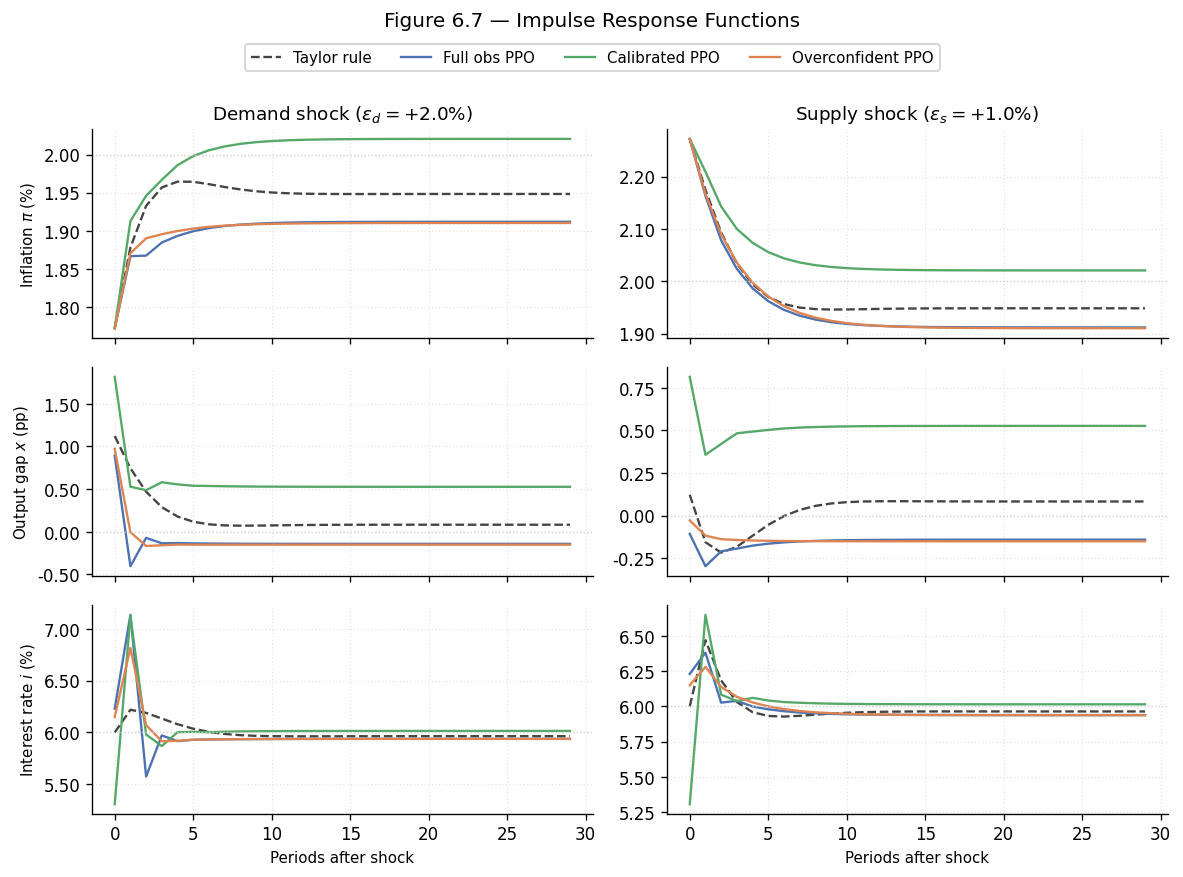

In [ ]:
# Section 6.7 — Impulse Response Functions

import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# Load trained PPO models (seed=42)
ppo_models = {}
for condition in ["full_obs_rl", "pomdp_calibrated", "pomdp_overconfident"]:
    path = os.path.join(RESULTS_DIR, f"{condition}_seed42", "model.zip")
    if os.path.exists(path):
        ppo_models[condition] = PPO.load(path)
        print(f"  Loaded: {path}")
    else:
        print(f"  WARNING: {path} not found — skipping {condition}")


# IRF runner — deterministic post-shock

def run_irf(shock_type, shock_size, T=30, seed=42):
    conditions = {
        "Taylor rule":       ("full_obs",         None),
        "Full obs PPO":      ("full_obs",         ppo_models.get("full_obs_rl")),
        "Calibrated PPO":    ("pomdp_calibrated", ppo_models.get("pomdp_calibrated")),
        "Overconfident PPO": ("pomdp_overconf",   ppo_models.get("pomdp_overconfident")),
    }

    results = {}
    for label, (mode, model) in conditions.items():
        if mode != "full_obs" and model is None:
            continue
        if mode == "full_obs" and model is None and label != "Taylor rule":
            continue

        loader = None
        if mode == "pomdp_calibrated":
            loader = PlaceholderLoader(sigma_pi=SIGMA_PI_CALIB, sigma_x=SIGMA_X_CALIB,
                                       noise_scale=0.0, seed=seed)
        elif mode == "pomdp_overconf":
            loader = PlaceholderLoader(sigma_pi=SIGMA_PI_OVERC, sigma_x=SIGMA_X_OVERC,
                                       noise_scale=0.0, seed=seed)

        env = NKEnv(mode=mode, loader=loader, ep_len=T + 10, seed=seed)
        obs, _ = env.reset(seed=seed)

        if shock_type == "demand":
            env.eps_d = shock_size
            env.eps_s = 0.0
        else:
            env.eps_s = shock_size
            env.eps_d = 0.0

        pi_path, x_path, i_path = [], [], []

        for t in range(T):
            if label == "Taylor rule":
                action = np.array([env.taylor_action(clip=True)])
            else:
                action, _ = model.predict(obs, deterministic=True)

            obs, _, term, trunc, info = env.step(action)
            pi_path.append(info["pi"])
            x_path.append(info["x"])
            i_path.append(info["i"])

            env.eps_d   = 0.0
            env.eps_s   = 0.0
            env.SIGMA_D = 0.0
            env.SIGMA_S = 0.0

            if term or trunc:
                break

        results[label] = {
            "pi": np.array(pi_path),
            "x":  np.array(x_path),
            "i":  np.array(i_path),
        }

    return results

# IRF plotter

def plot_irf_combined(demand_results, supply_results, T=30, filename=None):
    fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True)

    series = [
        ("pi", r"Inflation $\pi$ (%)",   NKEnv.PI_STAR),
        ("x",  r"Output gap $x$ (pp)",   0.0),
        ("i",  r"Interest rate $i$ (%)", NKEnv.R_N + NKEnv.PI_STAR),
    ]
    periods  = np.arange(T)
    col_data = [
        (demand_results, r"Demand shock ($\varepsilon_d = +2.0\%$)"),
        (supply_results, r"Supply shock ($\varepsilon_s = +1.0\%$)"),
    ]

    for col, (results, col_title) in enumerate(col_data):
        for row, (key, ylabel, hline) in enumerate(series):
            ax = axes[row, col]
            for label, data in results.items():
                arr = data[key]
                n   = min(len(arr), T)
                ax.plot(periods[:n], arr[:n],
                        color=COLORS[label], ls=LINESTYLES[label],
                        lw=1.4, label=label)
            ax.axhline(hline, color="lightgray", lw=0.8, ls=":")
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
            ax.grid(axis="y", alpha=0.3)
            if row == 0:
                ax.set_title(col_title, fontsize=11)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=9)
            if row == 2:
                ax.set_xlabel("Periods after shock", fontsize=9)

    # Single shared legend above both columns
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="upper center", ncol=4, fontsize=9,
               framealpha=0.9, bbox_to_anchor=(0.5, 1.01))
    fig.suptitle("Figure 6.7 — Impulse Response Functions", fontsize=12, y=1.04)

    plt.tight_layout()

    if filename:
        fig.savefig(os.path.join(FIGURES_DIR, filename), dpi=150, bbox_inches="tight")
        print(f"  Saved: {FIGURES_DIR}/{filename} \n")
    plt.show()


# Run both and plot combined
demand_irf = run_irf("demand", shock_size=2.0, T=30)
supply_irf = run_irf("supply", shock_size=1.0, T=30)

plot_irf_combined(demand_irf, supply_irf, T=30, filename="irf_combined.png")

In [ ]:
# IRF convergence diagnostics — long-run attractors
# Both shock types converge to the same attractor so we report once

rows = []
for label, data in demand_irf.items():
    rows.append({
        "Condition": label,
        "π (%)":     f"{data['pi'][-5:].mean():.4f}",
        "x (pp)":    f"{data['x'][-5:].mean():.4f}",
        "i (%)":     f"{data['i'][-5:].mean():.4f}",
    })
df_conv = pd.DataFrame(rows).set_index("Condition")
show_table(
    df_conv,
    title="Table 6.7 — IRF Long-run Attractors: Demand and Supply Shocks (mean of last 5 periods)",
    caption="Attractors are identical across demand and supply shocks — "
            "both AR(1) processes die out and the system returns to its "
            "deterministic fixed point under each policy."
)

,π (%),x (pp),i (%)
Condition,,,
Taylor rule,1.9483,0.0827,5.9638
Full obs PPO,1.9118,-0.1416,5.9383
Calibrated PPO,2.0207,0.5269,6.0145
Overconfident PPO,1.9102,-0.1513,5.9371


### 6.8 Policy Surfaces

To visualise what each agent learned, we evaluate the policy function
$i(\pi, x)$ over a grid of $\pi \in [\pi^* - 3\%, \pi^* + 3\%]$ and
$x \in [-4, 4]$ pp, holding $i_{t-1} = i^* = 6\%$. Figure 6.8a shows the
raw policy surfaces; Figure 6.8b shows the deviation
$\Delta i = i_{\text{agent}} - i_{\text{Taylor}}$ for each RL condition.

Full obs PPO deviates modestly from the Taylor rule, with the largest
differences at low inflation and positive output gap — suggesting the agent
has learned to weight output gap stabilisation more heavily than the Taylor
rule in that region, while tracking the Taylor surface closely elsewhere.
Calibrated PPO shows a similar but more muted deviation pattern, staying
closer to the Taylor surface overall.

Overconfident PPO exhibits the most systematic deviation and is the most
directly interpretable. Its $\Delta i$ surface is negative across high-inflation
regions of the state space — the agent consistently sets rates below the Taylor
benchmark precisely where the Taylor rule demands the most aggressive response.
This is the geometric expression of a sub-unity $\hat{\phi}_{\pi,LR}$: a policy
surface that is flatter in the inflation dimension than the Taylor rule, failing
to raise rates proportionally as inflation rises above target. Where the Taylor
rule prescribes a 1.5 pp rate increase per 1 pp of inflation, the overconfident
agent's surface rises by less — a shortfall that is visually apparent in the
deviation plot and analytically confirmed by the regression coefficient of 0.832
in Section 6.3.

The interpretation connects directly to the belief-state structure. Because the
overconfident agent receives narrow $\hat{\sigma}$ intervals, it treats each
inflation observation as a near-certain signal and calibrates its response
accordingly — but the response it has learned is tuned to a constant low-noise
environment, not to the magnitude of deviation from target. The result is a
surface that reacts to the direction of inflation but not to its scale in the
way the Taylor principle requires. Calibrated PPO, by contrast, has learned
under wider uncertainty signals and has developed a more conservative surface
that does not systematically underrespond in high-inflation regions — consistent
with its higher $\hat{\phi}_{\pi,LR}$ and its mild overshoot in the IRF analysis.

Taken together, the policy surface deviation plots provide the geometric proof
of what the Taylor regression measures statistically and the IRFs trace
dynamically: overconfident belief states produce a structurally shallower
inflation response, and calibrated belief states produce a surface that more
closely approximates the Taylor rule's determinacy properties.


  Saved: figures/policy_surfaces.png


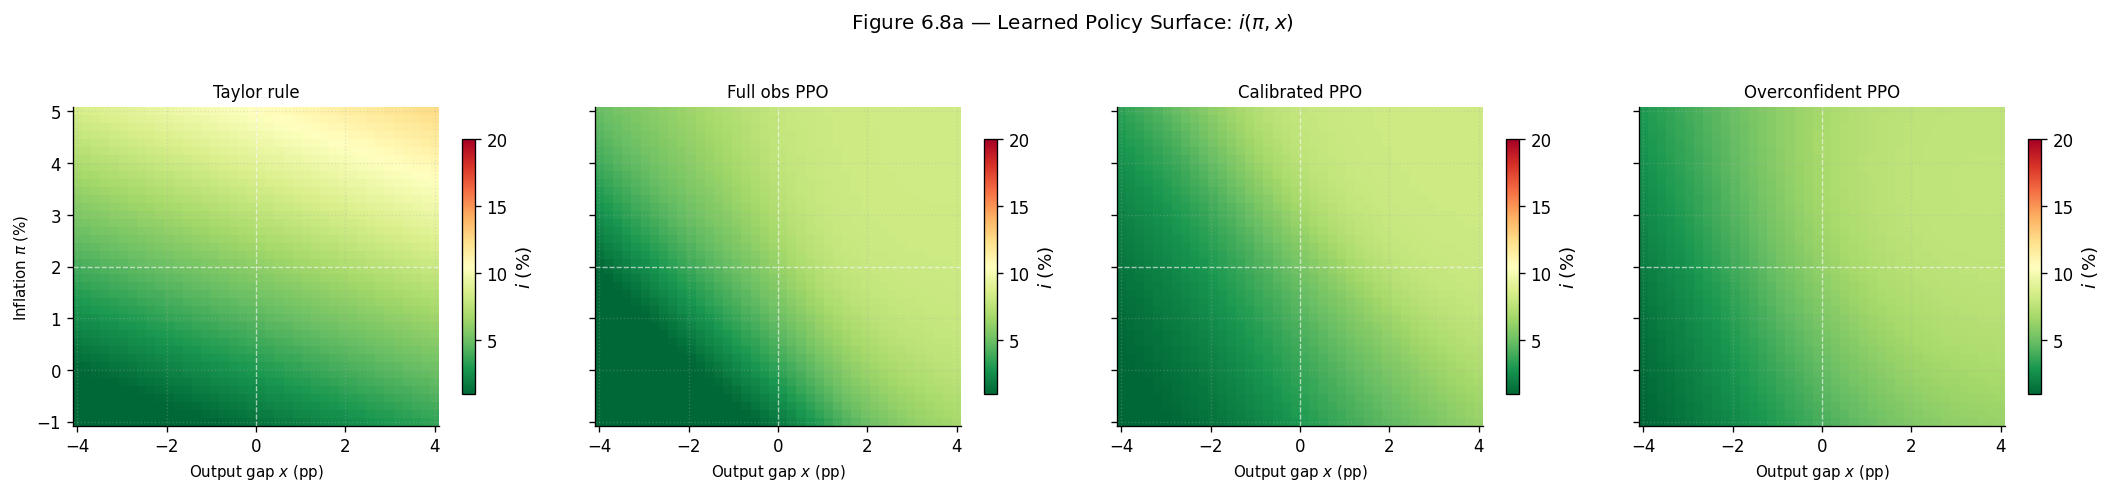


  Saved: figures/policy_deviations.png


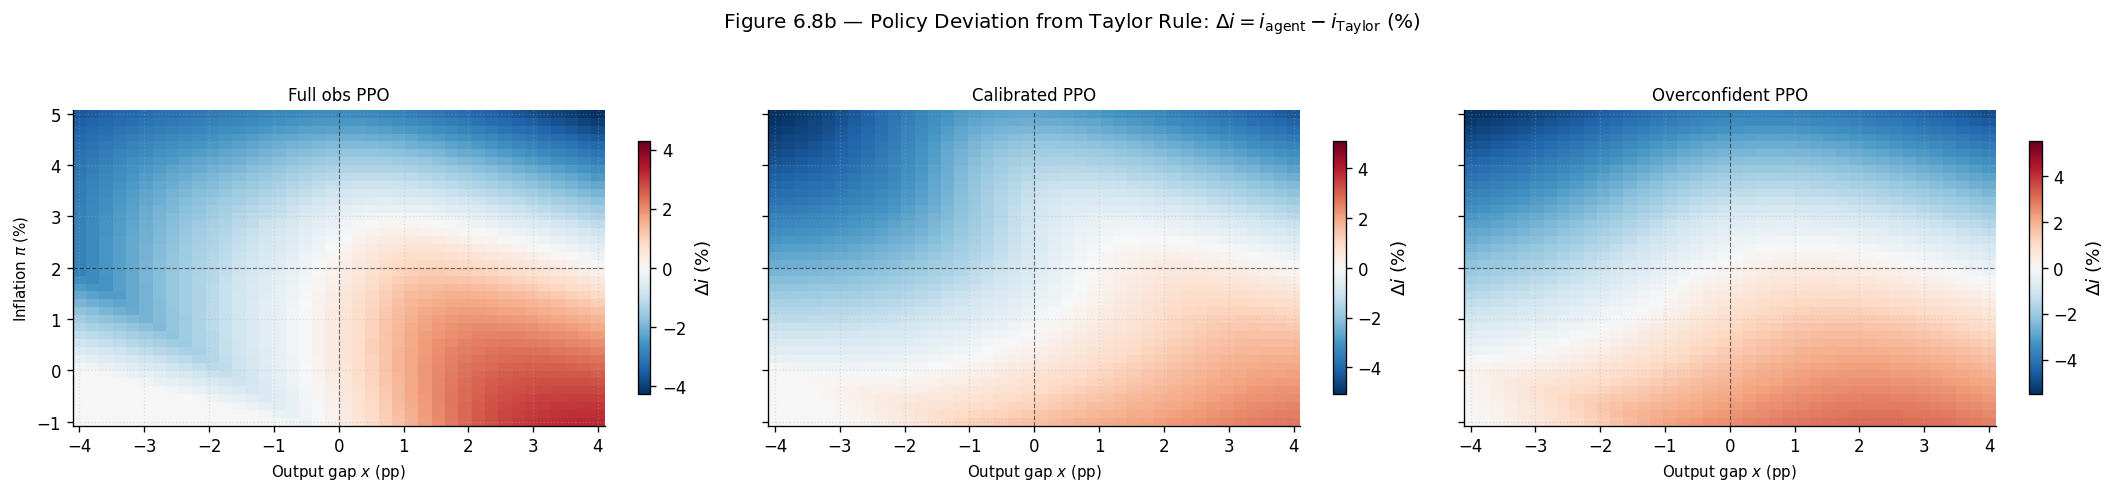

In [ ]:
# Policy Surfaces

import warnings
warnings.filterwarnings("ignore")

# Load models (reuse ppo_models if already loaded, otherwise reload)
if "ppo_models" not in dir() or not ppo_models:
    ppo_models = {}
    for condition in ["full_obs_rl", "pomdp_calibrated", "pomdp_overconfident"]:
        path = os.path.join(RESULTS_DIR, f"{condition}_seed42", "model.zip")
        if os.path.exists(path):
            ppo_models[condition] = PPO.load(path)
            print(f"  Loaded: {path}")

# Policy surface computation

def compute_policy_surface(label, mode, model, pi_grid, x_grid, i_prev=6.0, seed=42):
    loader = None
    if mode == "pomdp_calibrated":
        loader = PlaceholderLoader(sigma_pi=SIGMA_PI_CALIB, sigma_x=SIGMA_X_CALIB,
                                   noise_scale=0.0, seed=seed)
    elif mode == "pomdp_overconf":
        loader = PlaceholderLoader(sigma_pi=SIGMA_PI_OVERC, sigma_x=SIGMA_X_OVERC,
                                   noise_scale=0.0, seed=seed)

    surface = np.zeros((len(pi_grid), len(x_grid)))

    for i, pi_val in enumerate(pi_grid):
        for j, x_val in enumerate(x_grid):
            if label == "Taylor rule":
                i_t = (NKEnv.R_N + NKEnv.PI_STAR
                       + NKEnv.PHI_PI * (pi_val - NKEnv.PI_STAR)
                       + NKEnv.PHI_Y  * x_val)
                surface[i, j] = float(np.clip(i_t, NKEnv.I_MIN, NKEnv.I_MAX))
            else:
                if mode == "full_obs":
                    obs = np.array([pi_val, x_val, i_prev], dtype=np.float32)
                else:
                    belief = loader.get(0, pi_val, x_val)
                    obs    = np.array([belief[0], belief[1],
                                       belief[2], belief[3],
                                       i_prev], dtype=np.float32)
                action, _ = model.predict(obs, deterministic=True)
                surface[i, j] = float(np.clip(action.item(),
                                               NKEnv.I_MIN, NKEnv.I_MAX))
    return surface


# Build grid
PI_VALS = np.linspace(NKEnv.PI_STAR - 3.0, NKEnv.PI_STAR + 3.0, 40)
X_VALS  = np.linspace(-4.0, 4.0, 40)
X_MESH, PI_MESH = np.meshgrid(X_VALS, PI_VALS)

surface_specs = [
    ("Taylor rule",       "full_obs",         None),
    ("Full obs PPO",      "full_obs",         ppo_models.get("full_obs_rl")),
    ("Calibrated PPO",    "pomdp_calibrated", ppo_models.get("pomdp_calibrated")),
    ("Overconfident PPO", "pomdp_overconf",   ppo_models.get("pomdp_overconfident")),
]

surfaces = {}
for label, mode, model in surface_specs:
    if model is None and label != "Taylor rule":
        print(f"  Skipping {label} — model not loaded")
        continue
    surfaces[label] = compute_policy_surface(label, mode, model, PI_VALS, X_VALS)

# Figure 6.8a — Policy surfaces

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.suptitle(r"Figure 6.8a — Learned Policy Surface: $i(\pi, x)$",
             fontsize=12, y=1.02)

vmin, vmax = NKEnv.I_MIN, NKEnv.I_MAX

for ax, (label, surface) in zip(axes, surfaces.items()):
    im = ax.pcolormesh(X_MESH, PI_MESH, surface,
                       cmap="RdYlGn_r", vmin=vmin, vmax=vmax, shading="auto")
    ax.axvline(0,             color="white", lw=0.8, ls="--", alpha=0.6)
    ax.axhline(NKEnv.PI_STAR, color="white", lw=0.8, ls="--", alpha=0.6)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(r"Output gap $x$ (pp)", fontsize=9)
    fig.colorbar(im, ax=ax, label="$i$ (%)", shrink=0.8)

axes[0].set_ylabel(r"Inflation $\pi$ (%)", fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "policy_surfaces.png"),
            dpi=150, bbox_inches="tight")
print("\n  Saved: figures/policy_surfaces.png")
plt.show()

# Figure 6.8b — Policy deviation from Taylor rule


taylor_surface = surfaces.get("Taylor rule")
if taylor_surface is not None:
    deviation_labels = ["Full obs PPO", "Calibrated PPO", "Overconfident PPO"]
    available        = [l for l in deviation_labels if l in surfaces]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)
    fig.suptitle(r"Figure 6.8b — Policy Deviation from Taylor Rule: "
                 r"$\Delta i = i_{\mathrm{agent}} - i_{\mathrm{Taylor}}$ (%)",
                 fontsize=12, y=1.02)

    for ax, label in zip(axes, available):
        diff = surfaces[label] - taylor_surface
        lim  = max(abs(diff.min()), abs(diff.max()))
        im   = ax.pcolormesh(X_MESH, PI_MESH, diff,
                             cmap="RdBu_r", vmin=-lim, vmax=lim, shading="auto")
        ax.axvline(0,             color="black", lw=0.7, ls="--", alpha=0.5)
        ax.axhline(NKEnv.PI_STAR, color="black", lw=0.7, ls="--", alpha=0.5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel(r"Output gap $x$ (pp)", fontsize=9)
        fig.colorbar(im, ax=ax, label=r"$\Delta i$ (%)", shrink=0.8)

    axes[0].set_ylabel(r"Inflation $\pi$ (%)", fontsize=9)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, "policy_deviations.png"),
                dpi=150, bbox_inches="tight")
    print("\n  Saved: figures/policy_deviations.png")
    plt.show()

## Section 7: Discussion

The central finding of this project is that belief-state calibration quality affects the structure of the learned monetary policy more than its raw welfare performance. Across three seeds, calibrated PPO achieves a higher mean long-run inflation response coefficient ($\hat{\phi}_{\pi,LR} = 0.967$) than overconfident PPO ($\hat{\phi}_{\pi,LR} = 0.880$), and is the only POMDP condition that ever satisfies the Taylor principle outright. Yet on raw welfare loss, the overconfident agent performs similarly to or better than the calibrated agent ($-6.04$ vs $-6.95$). These two findings reflect different dimensions of policy quality that are affected in different directions by calibration. The overconfident agent, receiving narrow and artificially certain belief states, learns a tight reactive policy well-suited to minimising loss under constant-$\sigma$ training noise. The calibrated agent, receiving wider and more informative uncertainty signals, learns a more cautious policy that sits closer to the Taylor compliance threshold but accepts a slightly higher welfare cost. We hypothesise that this tradeoff would invert under genuine shock-contingent uncertainty: the calibrated agent has learned to treat high-variance observations as signals for caution, whereas the overconfident agent treats all observations as near-certain and acts reactively regardless of true state uncertainty. Under a COVID-style regime shift where true uncertainty widens, this difference in learned policy structure would be expected to produce worse outcomes for the overconfident agent despite its superior in-distribution welfare performance — though testing this requires extending the `PlaceholderLoader` to time-varying $\sigma$ and is left for future work.

The welfare-structure tension admits a normative resolution. Raw CB loss measures in-sample stabilisation performance under the training distribution — a constant-$\sigma$ regime that never simulates genuine uncertainty episodes. The Taylor principle, by contrast, is a structural stability condition: an agent that violates it may perform well in-distribution while remaining vulnerable to self-fulfilling inflation dynamics under regime change. From this perspective, structure is the more policy-relevant criterion, and the calibrated agent's advantage on $\hat{\phi}_{\pi,LR}$ — achieved despite operating under greater observation uncertainty — is the more meaningful finding. The welfare gap ($-6.95$ vs $-6.04$) reflects the cost of learning a structurally sound policy under the conservative constant-$\sigma$ regime; we hypothesise this cost would disappear or invert under time-varying uncertainty where the calibrated agent's wider intervals correctly signal genuine distributional shift. Crucially, an overconfident agent that achieves better in-sample welfare but violates the Taylor principle is optimising for the wrong objective: determinacy is an out-of-sample stability property that in-sample loss cannot capture.

The convergence-speed ordering provides a second, independent piece of evidence.
Full observability converges fastest (~450k timesteps), calibrated follows (~700k), and overconfident is last (~900k). This is counterintuitive under a simple "wider noise → harder credit assignment → slower convergence" reading, which would predict calibrated converging last. A more consistent interpretation is that overconfident agents commit prematurely to a near-deterministic policy that violates the Taylor principle, and must escape this local minimum before improving further. Calibrated agents, guided by wider belief-state intervals, explore the state space more broadly and discover the Taylor-compliant region earlier. This directly connects the convergence result to the Taylor compliance result, with both pointing to the same underlying mechanism: overconfident belief states encourage premature exploitation at the cost of policy structure.

The SAC comparison qualifies the PPO finding in an important way. Under SAC,
the overconfident condition satisfies the Taylor principle in all three seeds
(mean $\hat{\phi}_{\pi,LR} = 1.173$) and the calibrated condition satisfies it
in 2/3 seeds (mean $\hat{\phi}_{\pi,LR} = 1.169$), with seed=123 the single
exception. Both conditions converge in approximately 10,000 timesteps — roughly 50–90× faster than PPO. The overconfident policy collapse observed under PPO
is therefore not an inevitable consequence of overconfident belief states; it is
partly an algorithm-specific failure that SAC's entropy regularisation prevents.
Maximum-entropy methods, by construction, resist premature policy commitment —
the same mechanism that protects against overconfident inputs. This suggests that the interaction between calibration quality and learning algorithm is itself an important variable: practitioners deploying RL-based policy rules with imperfectly calibrated forecasters may be able to compensate at the algorithm level by choosing entropy-regularised methods over on-policy approaches.

This paper makes a specific empirical contribution to the emerging literature on
RL-based monetary policy. Prior work (Chen et al., 2025) has treated the forecaster's predictive distribution as a point estimate or assumed well-calibrated uncertainty. We show that this assumption is consequential: two
agents receiving identical point predictions but different uncertainty estimates
learn structurally different policies, with the calibrated agent more closely
approximating the Taylor rule's determinacy properties. The finding is modest in
magnitude and not fully robust across seeds, and the welfare ordering runs counter to the central hypothesis — but it identifies a channel through which forecaster calibration propagates into policy structure that has not previously been documented.

Several limitations constrain the strength of our conclusions. First, the
`PlaceholderLoader` supplies belief states with constant $\sigma$ values throughout training, meaning the agent never experiences the widening of uncertainty intervals that a real Bayesian forecaster would produce during regime shifts. The calibration advantage is therefore tested in a conservative setting — if anything, the effect of calibration quality would be stronger under time-varying $\sigma$. Second, three seeds is a small sample; the per-seed Taylor compliance ordering is not fully consistent (seed=123 produces a near-tie; seed=7 favours overconfident marginally), and with only three seeds no formal inference is possible — we report directional means ($\hat{\phi}_{\pi,LR} = 0.967$ vs $0.880$) without bootstrap confidence intervals or pairwise $t$-tests, and the calibrated-vs-overconfident comparison should be read as suggestive rather than statistically established. Third, the NK model is a linearised benchmark that abstracts from nonlinearities, zero lower bound constraints, and fiscal-monetary interactions present in real policy
settings. Fourth, episode length $T=20$ suppresses aggressive inflation responses — the episode-length robustness analysis in Section 6.4 shows $\hat{\phi}_{\pi,LR}$ declining with $T$ for all conditions. Importantly, however, calibrated PPO maintains the highest $\hat{\phi}_{\pi,LR}$ at every episode length tested, suggesting the directional ordering is robust to this design choice even if the absolute level is not.

## Section 8: Conclusion

This project investigated whether the calibration quality of an upstream Bayesian
forecaster — specifically, the alignment between its predictive uncertainty
estimates and the underlying data-generating process — affects the policy that an
RL agent learns when that forecaster supplies the agent's belief state. We used
$\sigma$ values from a calibrated MS-GLSTM and an overconfident MC Dropout LSTM
to parameterise belief states in a Three-Equation New Keynesian POMDP, trained
PPO and SAC agents under both belief-state regimes plus a full-observability
control across three seeds, and evaluated the resulting policies on welfare loss,
Taylor principle compliance, impulse-response behaviour, and policy structure.

Our central finding is that calibration of the belief state's predictive
distribution affects the *structural* properties of the learned policy more than
its raw welfare performance. Across three seeds, the calibrated PPO agent achieves
a higher mean $\hat{\phi}_{\pi,LR}$ of 0.967 vs 0.880 for overconfident and is
the only POMDP condition that ever clears the determinacy threshold; the
overconfident agent never satisfies the Taylor principle. The asymmetry maps
directly onto the impulse-response behaviour, where calibrated PPO overshoots the
inflation target and overconfident PPO undershoots — a mechanistic signature of
the regression ordering. Yet on raw welfare loss, the overconfident agent performs
better under the constant-$\sigma$ training regime ($-6.04$ vs $-6.95$, a roughly
13\% gap on raw CB loss), reflecting a tighter reactive policy that is well-suited
to the observed in-distribution noise structure. We interpret this
welfare/structure tradeoff as evidence that calibration produces a different
*kind* of policy — more cautious and Taylor-aligned under calibrated inputs, more
reactive under overconfident inputs — rather than simply a better one. The SAC comparison provides a useful qualifier: under entropy-regularised maximum-entropy methods, both belief-state conditions satisfy the Taylor principle in a majority of seeds and the overconfident policy collapse observed under PPO is substantially reduced. The vulnerability of
on-policy methods to overconfident inputs is therefore partly an algorithm-specific
failure that maximum-entropy approaches can correct.

Three caveats bear on the generalisability of these findings. The constant-$\sigma$
`PlaceholderLoader` is a conservative test of the calibration hypothesis — it
isolates the effect of $\sigma$ magnitude but suppresses the time-varying $\sigma$
behaviour that a real Bayesian forecaster would produce during regime shifts, where
we hypothesise the calibration advantage would be larger, though this remains
untested. Three seeds is a small sample, and the per-seed Taylor compliance
ordering is mixed in level even when robust in mean direction. The NK environment
is a linearised benchmark that abstracts from nonlinearities, the zero lower
bound, and fiscal-monetary interactions present in real policy settings.

These caveats notwithstanding, our results identify a candidate channel through which
forecaster calibration propagates into RL-learned policy structure, which to our
knowledge has not been documented in prior work on RL-based monetary policy. For
practitioners considering RL-based monetary policy rules, the implication is that
forecaster calibration deserves consideration as a design variable rather than
being treated as a downstream concern, and that the choice of learning algorithm
— particularly whether maximum-entropy regularisation is used — interacts
non-trivially with the quality of the upstream uncertainty estimates supplied to
the agent. We see two natural extensions: replacing the constant-$\sigma$
`PlaceholderLoader` with a forecaster that produces time-varying $\sigma$ during
the RL training loop, and extending the analysis to richer environments (DSGE with
frictions, ZLB regimes, or multi-country settings) to test whether the
structural-not-welfare framing generalises beyond the linearised three-equation
benchmark used here.

## References

Carlin, W., & Soskice, D. (2005). The 3-equation New Keynesian model — a graphical exposition. *The B.E. Journal of Macroeconomics*, *5*(1), 1–36.

Chen, M., Cont, R., Joseph, A., Kumhof, M., Pan, X., Xiong, W., & Zhou, X. (2025). *Deep reinforcement learning in a monetary model.* Bank of England Staff Working Paper No. 1,142.

Clarida, R., Galí, J., & Gertler, M. (1999). The science of monetary policy: A New Keynesian perspective. *Journal of Economic Literature*, *37*(4), 1661–1707.

Gal, Y., & Ghahramani, Z. (2016). Dropout as a Bayesian approximation: Representing model uncertainty in deep learning. In *Proceedings of the 33rd International Conference on Machine Learning (ICML)*, *48*, 1050–1059.

Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S. (2018). Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor. In *Proceedings of the 35th International Conference on Machine Learning (ICML)*, *80*, 1861–1870.

Raffin, A., Hill, A., Gleave, A., Kanervisto, A., Ernestus, M., & Dormann, N. (2021). Stable-Baselines3: Reliable reinforcement learning implementations. *Journal of Machine Learning Research*, *22*(268), 1–8.

Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). *Proximal policy optimization algorithms.* arXiv preprint arXiv:1707.06347.

Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. In *Proceedings of the 9th Python in Science Conference (SciPy)*, 92–96.

Smets, F., & Wouters, R. (2007). Shocks and frictions in US business cycles: A Bayesian DSGE approach. *American Economic Review*, *97*(3), 586–606.

Taylor, J. B. (1993). Discretion versus policy rules in practice. *Carnegie-Rochester Conference Series on Public Policy*, *39*, 195–214.

Towers, M., Kwiatkowski, A., Terry, J., Balis, J. U., De Cola, G., Deleu, T., Goulão, M., Kallinteris, A., Krimmel, M., KG, A., Perez-Vicente, R., Pierré, A., Schulhoff, S., Tai, J. J., Tan, H., & Younis, O. G. (2024). *Gymnasium: A standard interface for reinforcement learning environments.* arXiv preprint arXiv:2407.17032.

Wang, T., Feinstein, K., & Chen, S. (2025). *Reinforcement learning for monetary policy under macroeconomic uncertainty: Analyzing tabular and function approximation methods.* arXiv preprint arXiv:2512.17929.